# Medical Robotics Project

1. **YOLO + Depth Anything V2**
2. **U-Net + Depth Anything V2**

The dataset was exported in two architecture-specific formats. Both formats contain the same annotated frames and share the same train/validation/test split. The YOLO representation stores polygon annotations, whereas the U-Net representation stores raster masks and preview images. The two representations are complementary views of the same underlying dataset.

```text
YOLO dataset
    ├── images
    ├── labels       → tool segmentation
    └── tti_labels   → TTI segmentation/detection

U-Net dataset
    ├── images
    ├── masks        → tool segmentation
    ├── tti_masks    → TTI/contact ground truth
    ├── preview_masks
    └── preview_tti_masks
```

| Information             | YOLO Dataset                     | U-Net Dataset                    |
|-------------------------|----------------------------------|----------------------------------|
| Images                  | Yes                              | Yes                              |
| Train/val/test split    | Yes                              | Yes                              |
| Tool polygons           | Yes, in `labels`                 | No, represented as masks         |
| TTI polygons            | Yes, in `tti_labels`             | No, represented as TTI masks    |
| Tool raster masks       | No or not required               | Yes, in `masks/mask`             |
| TTI raster masks        | No or not required               | Yes, in `tti_masks`              |
| Colored previews        | Not required                     | Yes, for visual inspection       |
| YOLO training           | Direct                           | Not directly supported           |
| U-Net training          | Not directly supported           | Direct                           |
| Contact/TTI evaluation  | Polygon labels available         | TTI masks available              |

For comparison:

```text
YOLO tool mask ─────┐
                    ├── Depth Anything V2 ── contact isolation
U-Net tool mask ────┘
```

@misc{jocher2026ultralyticsyolo26unifiedrealtime,
  title = {Ultralytics YOLO26: Unified Real-Time End-to-End Vision Models},
  author = {Glenn Jocher and Jing Qiu and Mengyu Liu and Shuai Lyu and Fatih Cagatay Akyon and Muhammet Esat Kalfaoglu},
  year = {2026},
  eprint = {2606.03748},
  archivePrefix = {arXiv},
  primaryClass = {cs.CV},
  doi = {10.48550/arXiv.2606.03748},
  url = {https://arxiv.org/abs/2606.03748},
}




## Dataset setup

Before running the code, download the YOLO and U-Net datasets and save them as folders in the project directory with the following names:

- `yolo_dataset`
- `unet_dataset`

The expected directory structure is:

```text
project_directory/
├── yolo_dataset/
├── unet_dataset/
└── program(yolo+unet).ipynb
```

Make sure that both dataset folders contain all the required images, labels, and annotations before executing the code.


## Imports

In [1]:

import time
import random
import yaml
import sys
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import pipeline

from scipy.ndimage import distance_transform_edt
from torch.utils.data import WeightedRandomSampler


from ultralytics import YOLO, settings

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

/home/federico-ai-rob/Scrivania/AIRO/MR_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /home/federico-ai-rob/Scrivania/AIRO/MR_project/.venv/bin/python
PyTorch: 2.11.0+cu128
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## Dataset Split Consistency Check

In [2]:
PROJECT_ROOT = Path(
    ""
).resolve()

YOLO_ROOT = (
    PROJECT_ROOT
    / "yolo_dataset"
)

UNET_ROOT = (
    PROJECT_ROOT
    / "unet_dataset"
)

In [3]:
def get_image_files(directory):
    directory = Path(directory)

    if not directory.exists():
        return []

    image_files = []

    for pattern in [
        "*.png",
        "*.jpg",
        "*.jpeg",
        "*.bmp",
        "*.tif",
        "*.tiff",
    ]:
        image_files.extend(
            directory.glob(pattern)
        )

    return sorted(image_files)


def get_image_stems(directory):
    return {
        path.stem
        for path in get_image_files(directory)
    }


def compare_image_splits(
    yolo_root,
    unet_root,
):
    yolo_root = Path(yolo_root)
    unet_root = Path(unet_root)

    for split in [
        "train",
        "val",
        "test",
    ]:
        yolo_stems = get_image_stems(
            yolo_root / "images" / split
        )

        unet_stems = get_image_stems(
            unet_root / "images" / split
        )

        only_yolo = sorted(
            yolo_stems - unet_stems
        )

        only_unet = sorted(
            unet_stems - yolo_stems
        )

        print(f"\n{split.upper()}")
        print("YOLO:", len(yolo_stems))
        print("U-Net:", len(unet_stems))
        print("YOLO only:", len(only_yolo))
        print("U-Net only:", len(only_unet))

        if only_yolo:
            print(
                "Examples found only in YOLO:",
                only_yolo[:5],
            )

        if only_unet:
            print(
                "Examples found only in U-Net:",
                only_unet[:5],
            )


compare_image_splits(
    yolo_root=YOLO_ROOT,
    unet_root=UNET_ROOT,
)


TRAIN
YOLO: 2880
U-Net: 2880
YOLO only: 0
U-Net only: 0

VAL
YOLO: 760
U-Net: 760
YOLO only: 0
U-Net only: 0

TEST
YOLO: 182
U-Net: 182
YOLO only: 0
U-Net only: 0


# YOLO

### Functions

In [4]:
def ensure_dir(path):
    Path(path).mkdir(
        parents=True,
        exist_ok=True,
    )


def resolve_device(device=None):
    if device is not None:
        return device

    return 0 if torch.cuda.is_available() else "cpu"


def get_image_files(directory):
    directory = Path(directory)

    image_paths = []

    for pattern in [
        "*.jpg",
        "*.jpeg",
        "*.png",
        "*.bmp",
        "*.tif",
        "*.tiff",
    ]:
        image_paths.extend(
            directory.glob(pattern)
        )

    return sorted(image_paths)


def save_image(path, image):
    path = Path(path)

    ensure_dir(path.parent)

    if not cv2.imwrite(
        str(path),
        image,
    ):
        raise IOError(
            f"Unable to save image: {path}"
        )


def overlay_mask(
    image_bgr,
    mask,
    color=(0, 255, 255),
    alpha=0.45,
):
    colored = image_bgr.copy()
    colored[mask > 0] = color

    return cv2.addWeighted(
        colored,
        alpha,
        image_bgr,
        1.0 - alpha,
        0,
    )

### Configuration

In [5]:
PROJECT_ROOT = Path(
    ""
).resolve()

In [6]:
settings.update({
    "runs_dir": str(
        PROJECT_ROOT
        / "outputs"
    )
})

In [7]:
cfg = {
    "device": None,

    "dataset_root": (
        PROJECT_ROOT
        / "yolo_dataset"
    ),

    "data_yaml": (
        PROJECT_ROOT
        / "configs"
        / "data_tools_yolo26.yaml"
    ),

    "base_weights": "yolo26n-seg.pt",

    "image_size": 640,
    "batch_size": 16,
    "epochs": 85,
    "patience": 100,

    "project": (
        PROJECT_ROOT
        / "outputs"
        / "yolo26"
    ),

    "run_name": "train_yolo26",
    "val_run_name": "val_yolo26",
    "inference_run_name": "inference_yolo26",
    "depth_run_name": "depth_yolo26",

    "confidence": 0.60,
}

YOLO_ROOT = Path(
    cfg["dataset_root"]
).resolve()

YOLO_DATA_YAML = Path(
    cfg["data_yaml"]
).resolve()

YOLO_OUTPUT_DIR = Path(
    cfg["project"]
).resolve()

TRAIN_OUTPUT_DIR = (
    YOLO_OUTPUT_DIR
    / cfg["run_name"]
)

VAL_OUTPUT_DIR = (
    YOLO_OUTPUT_DIR
    / cfg["val_run_name"]
)

INFERENCE_OUTPUT_DIR = (
    YOLO_OUTPUT_DIR
    / cfg["inference_run_name"]
)

DEPTH_OUTPUT_DIR = (
    YOLO_OUTPUT_DIR
    / cfg["depth_run_name"]
)

YOLO_DEVICE = resolve_device(
    cfg["device"]
)

ensure_dir(
    YOLO_DATA_YAML.parent
)

ensure_dir(
    YOLO_OUTPUT_DIR
)

ensure_dir(
    TRAIN_OUTPUT_DIR
)

ensure_dir(
    VAL_OUTPUT_DIR
)

ensure_dir(
    INFERENCE_OUTPUT_DIR
)

ensure_dir(
    DEPTH_OUTPUT_DIR
)

print("Project root:", PROJECT_ROOT)
print("Dataset:", YOLO_ROOT)
print("Data YAML:", YOLO_DATA_YAML)
print("YOLO output:", YOLO_OUTPUT_DIR)
print("Training output:", TRAIN_OUTPUT_DIR)
print("Validation output:", VAL_OUTPUT_DIR)
print("Inference output:", INFERENCE_OUTPUT_DIR)
print("Depth output:", DEPTH_OUTPUT_DIR)
print("Ultralytics runs_dir:", settings["runs_dir"])
print("Device:", YOLO_DEVICE)

Project root: /home/federico-ai-rob/Scrivania/AIRO/MR_project
Dataset: /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset
Data YAML: /home/federico-ai-rob/Scrivania/AIRO/MR_project/configs/data_tools_yolo26.yaml
YOLO output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo26
Training output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo26/train_yolo26
Validation output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo26/val_yolo26
Inference output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo26/inference_yolo26
Depth output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo26/depth_yolo26
Ultralytics runs_dir: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs
Device: 0


### YOLO Dataset

In [8]:
class_names = {
    0: "tool_0",
    1: "tool_1",
    2: "tool_2",
    3: "tool_3",
    4: "tool_4",
    5: "tool_5",
    6: "tool_6",
    7: "tool_7",
    8: "tool_8",
    9: "tool_9",
    10: "tool_10_UNUSED",
    11: "tool_11",
    12: "Unknown TTI",
    13: "Coagulation",
    14: "Other",
    15: "Retract and grab",
    16: "Blunt dissection",
    17: "Energy- sharp dissection",
    18: "Staple",
    19: "Retract and push",
    20: "Cut- sharp dissection",
}

data_config = {
    "path": str(
        YOLO_ROOT.resolve()
    ),

    "train": str(
        (
            YOLO_ROOT
            / "images"
            / "train"
        ).resolve()
    ),

    "val": str(
        (
            YOLO_ROOT
            / "images"
            / "val"
        ).resolve()
    ),

    "test": str(
        (
            YOLO_ROOT
            / "images"
            / "test"
        ).resolve()
    ),

    "names": class_names,
}

with open(
    YOLO_DATA_YAML,
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        data_config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print(
    "YAML file created:",
    YOLO_DATA_YAML.resolve(),
)

with open(
    YOLO_DATA_YAML,
    "r",
    encoding="utf-8",
) as file:
    print(file.read())


YAML file created: /home/federico-ai-rob/Scrivania/AIRO/MR_project/configs/data_tools_yolo26.yaml
path: /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset
train: /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset/images/train
val: /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset/images/val
test: /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset/images/test
names:
  0: tool_0
  1: tool_1
  2: tool_2
  3: tool_3
  4: tool_4
  5: tool_5
  6: tool_6
  7: tool_7
  8: tool_8
  9: tool_9
  10: tool_10_UNUSED
  11: tool_11
  12: Unknown TTI
  13: Coagulation
  14: Other
  15: Retract and grab
  16: Blunt dissection
  17: Energy- sharp dissection
  18: Staple
  19: Retract and push
  20: Cut- sharp dissection



In [9]:
for split in ["train", "val", "test"]:
    image_dir = YOLO_ROOT / "images" / split
    label_dir = YOLO_ROOT / "labels" / split

    image_count = len(
        get_image_files(image_dir)
    )

    label_count = len(
        list(label_dir.glob("*.txt"))
    )

    print(
        f"{split}: "
        f"{image_count} images, "
        f"{label_count} labels"
    )

train: 2880 images, 2880 labels
val: 760 images, 760 labels
test: 182 images, 182 labels


### YOLO stage

In [10]:
def predict_instances(
    model,
    image_bgr,
    confidence,
    device,
):
    """
    Runs YOLO26-seg on a single image and returns
    a list of predicted instances.

    Each instance contains:
    - a binary mask at the original resolution;
    - class_id;
    - confidence.
    """
    results = model.predict(
        source=image_bgr,
        conf=confidence,
        device=device,
        verbose=False,
    )

    result = results[0]
    height, width = image_bgr.shape[:2]

    if (
        result.masks is None
        or result.boxes is None
    ):
        return []

    masks = (
        result.masks.data
        .detach()
        .cpu()
        .numpy()
    )

    class_ids = (
        result.boxes.cls
        .detach()
        .cpu()
        .numpy()
        .astype(np.int64)
    )

    confidences = (
        result.boxes.conf
        .detach()
        .cpu()
        .numpy()
    )

    instances = []

    for mask, class_id, conf in zip(
        masks,
        class_ids,
        confidences,
    ):
        binary_mask = (
            mask > 0.5
        ).astype(np.uint8)

        binary_mask = cv2.resize(
            binary_mask,
            (width, height),
            interpolation=cv2.INTER_NEAREST,
        )

        instances.append({
            "mask": binary_mask,
            "class_id": int(class_id),
            "confidence": float(conf),
        })

    return instances


def merge_tool_masks(
    instances,
    image_shape,
):
    """
    Aggregates the masks of all instances/classes.

    Output:
    - 0: background;
    - 255: pixel belonging to a tool.
    """
    height, width = image_shape[:2]

    tool_mask = np.zeros(
        (height, width),
        dtype=np.uint8,
    )

    for instance in instances:
        tool_mask[
            instance["mask"] > 0
        ] = 255

    return tool_mask

### Model Training

In [11]:
model = YOLO(
    cfg["base_weights"]
)

start_time = time.time()

train_results = model.train(
    data=str(YOLO_DATA_YAML),
    task="segment",

    epochs=cfg["epochs"],
    imgsz=cfg["image_size"],
    batch=cfg["batch_size"],
    patience=cfg["patience"],

    device=YOLO_DEVICE,

    project=str(YOLO_OUTPUT_DIR),
    name=cfg["run_name"],
    exist_ok=True,
)

elapsed_minutes = (
    time.time() - start_time
) / 60.0

print(
    f"Training completed in "
    f"{elapsed_minutes:.2f} minutes."
)

New https://pypi.org/project/ultralytics/8.4.137 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.136 🚀 Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/federico-ai-rob/Scrivania/AIRO/MR_project/configs/data_tools_yolo26.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=85, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=No

### Verification Inference

Loads the best-trained weights and visually verifies the predicted mask on a test image.

In [12]:
best_weights = (
    TRAIN_OUTPUT_DIR
    / "weights"
    / "best.pt"
)

if not best_weights.exists():
    raise FileNotFoundError(
        "best.pt not found: "
        f"{best_weights.resolve()}"
    )

best_model = YOLO(
    str(best_weights)
)

print(
    "Best checkpoint loaded:",
    best_weights.resolve()
)

best_model.overrides.pop(
    "project",
    None,
)

best_model.overrides.pop(
    "name",
    None,
)

validation_results = best_model.val(
    data=str(YOLO_DATA_YAML),
    split="val",
    device=YOLO_DEVICE,

    project=str(YOLO_OUTPUT_DIR),
    name=cfg["val_run_name"],
    exist_ok=True,
)

print(
    "Validation completed."
)

print(
    "Validation output:",
    VAL_OUTPUT_DIR.resolve(),
)

Best checkpoint loaded: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo26/train_yolo26/weights/best.pt
Ultralytics 8.4.136 🚀 Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
YOLO26n-seg summary (fused): 139 layers, 2,692,979 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1089.4±715.5 MB/s, size: 660.1 KB)
val: Scanning /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset/labels/val.cache... 760 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 760/760 177.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 9.1it/s 5.3s<0.1s
                   all        760       1157      0.643      0.695       0.68      0.594      0.642      0.694      0.678      0.544
                tool_0         15         18          0          0          0          0          0          0          

In [13]:
test_images_dir = (
    YOLO_ROOT
    / "images"
    / "test"
)

test_image_paths = get_image_files(
    test_images_dir
)

if not test_image_paths:
    raise RuntimeError(
        "No images found in the test set."
    )

sample_path = test_image_paths[0]

image_bgr = cv2.imread(
    str(sample_path)
)

if image_bgr is None:
    raise RuntimeError(
        f"Image not readable: "
        f"{sample_path}"
    )

instances = predict_instances(
    model=best_model,
    image_bgr=image_bgr,
    confidence=cfg["confidence"],
    device=YOLO_DEVICE,
)

tool_mask = merge_tool_masks(
    instances=instances,
    image_shape=image_bgr.shape,
)

overlay = overlay_mask(
    image_bgr=image_bgr,
    mask=tool_mask,
)

print(
    "Number of predicted instances:",
    len(instances),
)

print(
    "Predicted classes:",
    [
        item["class_id"]
        for item in instances
    ],
)

print(
    "Confidence scores:",
    [
        round(
            item["confidence"],
            3,
        )
        for item in instances
    ],
)

Number of predicted instances: 1
Predicted classes: [1]
Confidence scores: [0.932]


In [14]:
inference_dir = INFERENCE_OUTPUT_DIR

ensure_dir(
    inference_dir
)

save_image(
    inference_dir / "input.png",
    image_bgr,
)

save_image(
    inference_dir / "tool_mask.png",
    tool_mask,
)

save_image(
    inference_dir / "overlay.png",
    overlay,
)

print(
    "Output salvati in:",
    inference_dir.resolve(),
)

Output salvati in: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo26/inference_yolo26


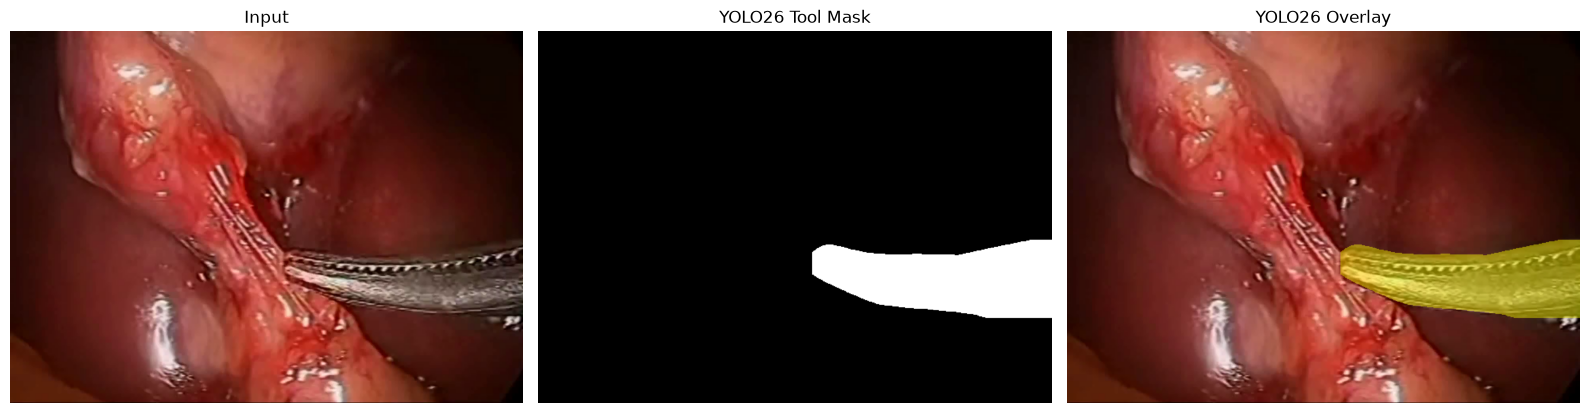

In [15]:
image_rgb = cv2.cvtColor(
    image_bgr,
    cv2.COLOR_BGR2RGB,
)

overlay_rgb = cv2.cvtColor(
    overlay,
    cv2.COLOR_BGR2RGB,
)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    tool_mask,
    cmap="gray",
)
plt.title("YOLO26 Tool Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_rgb)
plt.title("YOLO26 Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## DepthAnything v2

In [16]:
cfg["depth"] = {
    "enabled": True,
    "encoder": "vits",

    "quantile": 0.25,
    "min_area": 20,

    # True: select lower depth values
    # False: select higher depth values
    "use_low_depth": True,
}

DEPTH_OUTPUT_DIR = (
    YOLO_OUTPUT_DIR
    / cfg["depth_run_name"]
)

ensure_dir(
    DEPTH_OUTPUT_DIR
)

print(
    "Depth output:",
    DEPTH_OUTPUT_DIR.resolve()
)

Depth output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo26/depth_yolo26


In [17]:
class DepthAnythingV2Stage:
    def __init__(
        self,
        enabled=True,
        encoder="vits",
        checkpoint_path=None,
        device=None,
    ):
        self.enabled = enabled
        self.encoder = encoder
        self.checkpoint_path = checkpoint_path

        if device is None:
            self.device = torch.device(
                "cuda"
                if torch.cuda.is_available()
                else "cpu"
            )

        elif isinstance(device, torch.device):
            self.device = device

        elif device == 0:
            self.device = torch.device(
                "cuda"
            )

        else:
            self.device = torch.device(
                device
            )

        self.pipe = None

        if self.enabled:
            self._load_model()

    def _load_model(self):
        model_map = {
            "vits": (
                "depth-anything/"
                "Depth-Anything-V2-Small-hf"
            ),
            "vitb": (
                "depth-anything/"
                "Depth-Anything-V2-base-hf"
            ),
            "vitl": (
                "depth-anything/"
                "Depth-Anything-V2-Large-hf"
            ),
        }

        if self.encoder not in model_map:
            raise ValueError(
                f"Encoder not supported: "
                f"{self.encoder}. "
                "Use vits, vitb or vitl."
            )

        pipeline_device = (
            0
            if self.device.type == "cuda"
            else -1
        )

        self.pipe = pipeline(
            task="depth-estimation",
            model=model_map[self.encoder],
            device=pipeline_device,
        )

    @torch.no_grad()
    def infer(self, image_bgr):
        height, width = image_bgr.shape[:2]

        if not self.enabled:
            return np.zeros(
                (height, width),
                dtype=np.float32,
            )

        image_rgb = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB,
        )

        image_pil = Image.fromarray(
            image_rgb
        )

        output = self.pipe(image_pil)
        depth = output["depth"]

        if isinstance(depth, Image.Image):
            depth = np.asarray(depth)

        depth = np.asarray(
            depth,
            dtype=np.float32,
        )

        if depth.ndim == 3:
            depth = depth[..., 0]

        if depth.shape != (
            height,
            width,
        ):
            depth = cv2.resize(
                depth,
                (width, height),
                interpolation=cv2.INTER_LINEAR,
            )

        return depth

In [18]:
def normalize_depth(depth_map):
    depth_map = np.asarray(
        depth_map,
        dtype=np.float32,
    )

    depth_min = float(
        depth_map.min()
    )

    depth_max = float(
        depth_map.max()
    )

    if depth_max - depth_min < 1e-8:
        return np.zeros_like(
            depth_map
        )

    return (
        (depth_map - depth_min)
        / (depth_max - depth_min)
    )


### Contact Isolation

In [19]:
class FusionStage:
    def __init__(
        self,
        depth_quantile=0.25,
        min_area=20,
        use_low_depth=True,
    ):
        self.depth_quantile = depth_quantile
        self.min_area = min_area
        self.use_low_depth = use_low_depth

    def _remove_small_components(
        self,
        mask,
    ):
        if self.min_area <= 0:
            return mask

        binary = (
            mask > 0
        ).astype(np.uint8)

        num_labels, labels, stats, _ = (
            cv2.connectedComponentsWithStats(
                binary,
                connectivity=8,
            )
        )

        filtered = np.zeros_like(
            mask
        )

        for label_id in range(
            1,
            num_labels,
        ):
            area = stats[
                label_id,
                cv2.CC_STAT_AREA,
            ]

            if area >= self.min_area:
                filtered[
                    labels == label_id
                ] = 255

        return filtered

    def fuse(
        self,
        tool_mask,
        depth_map,
        debug=False,
    ):
        depth_norm = normalize_depth(
            depth_map
        )

        tool_region = (
            tool_mask > 0
        )

        tool_depth_values = (
            depth_norm[tool_region]
        )

        if tool_depth_values.size == 0:
            if debug:
                print(
                    "[Fusion] Tool mask empty."
                )

            return np.zeros_like(
                tool_mask,
                dtype=np.uint8,
            )

        depth_cutoff = np.quantile(
            tool_depth_values,
            self.depth_quantile,
        )

        if self.use_low_depth:
            depth_region = (
                depth_norm <= depth_cutoff
            )
        else:
            depth_region = (
                depth_norm >= depth_cutoff
            )

        contact_mask = (
            tool_region & depth_region
        ).astype(np.uint8) * 255

        if contact_mask.any():
            contact_mask = cv2.medianBlur(
                contact_mask,
                5,
            )

        contact_mask = (
            self._remove_small_components(
                contact_mask
            )
        )

        if debug:
            print(
                "[Fusion] Global depth min:",
                float(depth_norm.min()),
            )

            print(
                "[Fusion] Global depth max:",
                float(depth_norm.max()),
            )

            print(
                "[Fusion] Tool depth min:",
                float(tool_depth_values.min()),
            )

            print(
                "[Fusion] Tool depth max:",
                float(tool_depth_values.max()),
            )

            print(
                "[Fusion] Tool depth mean:",
                float(tool_depth_values.mean()),
            )

            print(
                "[Fusion] Depth cutoff:",
                float(depth_cutoff),
            )

            print(
                "[Fusion] Quantile:",
                self.depth_quantile,
            )

            print(
                "[Fusion] Tool coverage:",
                float(tool_region.mean()),
            )

            print(
                "[Fusion] Contact coverage:",
                float(
                    (contact_mask > 0).mean()
                ),
            )

        return contact_mask

### YOLO + DepthAnything V2 Pipeline


In [20]:
image_bgr = cv2.imread(
    str(sample_path)
)

if image_bgr is None:
    raise RuntimeError(
        f"Image not readable: {sample_path}"
    )

image_rgb = cv2.cvtColor(
    image_bgr,
    cv2.COLOR_BGR2RGB,
)

depth_stage = DepthAnythingV2Stage(
    enabled=cfg["depth"]["enabled"],
    encoder=cfg["depth"]["encoder"],
    device=YOLO_DEVICE,
)

instances = predict_instances(
    model=best_model,
    image_bgr=image_bgr,
    confidence=cfg["confidence"],
    device=YOLO_DEVICE,
)

yolo_tool_mask = merge_tool_masks(
    instances=instances,
    image_shape=image_bgr.shape,
)

depth_map = depth_stage.infer(
    image_bgr
)

depth_normalized = normalize_depth(
    depth_map
)

fusion_stage = FusionStage(
    depth_quantile=cfg["depth"]["quantile"],
    min_area=cfg["depth"]["min_area"],
    use_low_depth=cfg["depth"]["use_low_depth"],
)

yolo_contact_mask = fusion_stage.fuse(
    tool_mask=yolo_tool_mask,
    depth_map=depth_map,
    debug=True,
)

Loading weights: 100%|██████████| 287/287 [00:00<00:00, 4308.67it/s]


[Fusion] Global depth min: 0.0
[Fusion] Global depth max: 1.0
[Fusion] Tool depth min: 0.2549019753932953
[Fusion] Tool depth max: 1.0
[Fusion] Tool depth mean: 0.8690306544303894
[Fusion] Depth cutoff: 0.8352941274642944
[Fusion] Quantile: 0.25
[Fusion] Tool coverage: 0.07221792225662195
[Fusion] Contact coverage: 0.01868086978381096


In [21]:
save_image(
    DEPTH_OUTPUT_DIR
    / "input_yolo26.png",
    image_bgr,
)

save_image(
    DEPTH_OUTPUT_DIR
    / "yolo26_tool_mask.png",
    yolo_tool_mask,
)

save_image(
    DEPTH_OUTPUT_DIR
    / "depth_normalized_yolo26.png",
    (
        depth_normalized * 255
    ).clip(
        0,
        255,
    ).astype(np.uint8),
)

save_image(
    DEPTH_OUTPUT_DIR
    / "contact_mask_yolo26.png",
    yolo_contact_mask,
)

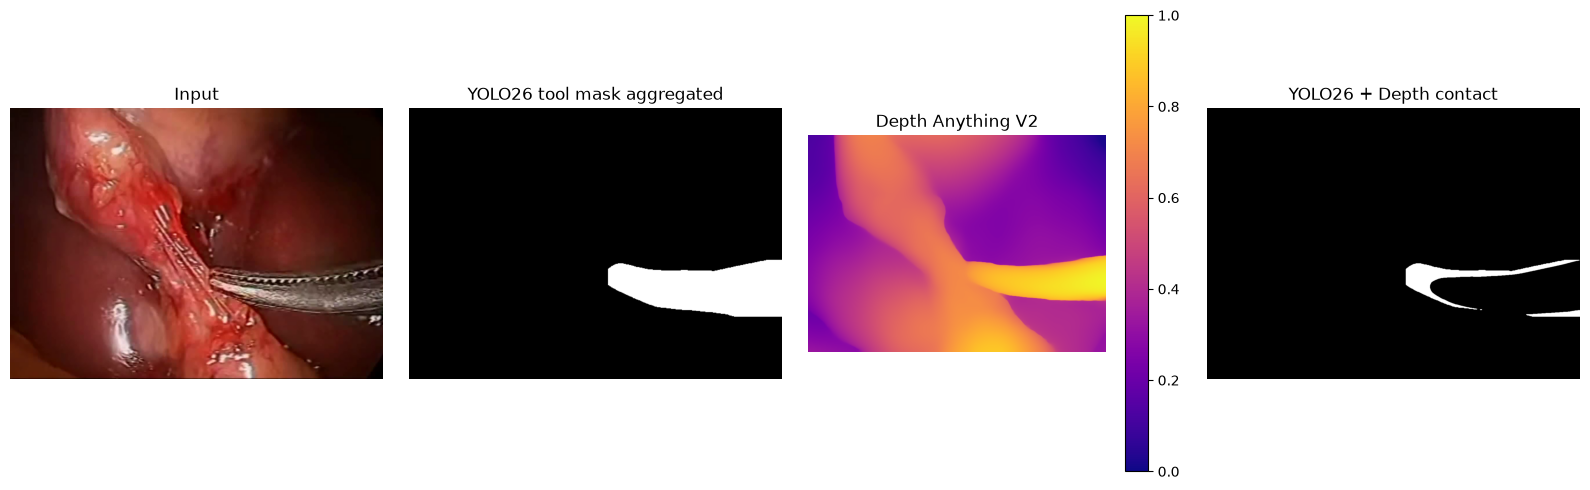

In [22]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(
    yolo_tool_mask,
    cmap="gray",
)
plt.title("YOLO26 tool mask aggregated")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(
    depth_normalized,
    cmap="plasma",
)
plt.title("Depth Anything V2")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 4, 4)
plt.imshow(
    yolo_contact_mask,
    cmap="gray",
)
plt.title("YOLO26 + Depth contact")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    DEPTH_OUTPUT_DIR
    / "depth_contact_yolo26.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### Depth Distribution inside the Tool Mask

In [23]:
tool_pixels = (
    yolo_tool_mask > 0
)

tool_depth_values = (
    depth_normalized[tool_pixels]
)

print(
    "Tool pixels:",
    tool_depth_values.size,
)

if tool_depth_values.size > 0:
    percentiles = np.percentile(
        tool_depth_values,
        [
            1,
            5,
            10,
            25,
            50,
            75,
            90,
            95,
            99,
        ],
    )

    print(
        "Depth values in tool mask:"
    )

    print(
        "min:",
        float(tool_depth_values.min()),
    )

    print(
        "max:",
        float(tool_depth_values.max()),
    )

    print(
        "mean:",
        float(tool_depth_values.mean()),
    )

    print(
        "percentiles:",
        percentiles,
    )

Tool pixels: 87334
Depth values in tool mask:
min: 0.2549019753932953
max: 1.0
mean: 0.8690306544303894
percentiles: [    0.33725     0.72549     0.77255     0.83529      0.8902     0.93333     0.96471     0.97647     0.98824]


### Comparing Low- and High-Depth Regions

In [24]:
fusion_low = FusionStage(
    depth_quantile=cfg["depth"]["quantile"],
    min_area=cfg["depth"]["min_area"],
    use_low_depth=True,
)

fusion_high = FusionStage(
    depth_quantile=cfg["depth"]["quantile"],
    min_area=cfg["depth"]["min_area"],
    use_low_depth=False,
)

contact_low = fusion_low.fuse(
    tool_mask=yolo_tool_mask,
    depth_map=depth_map,
    debug=True,
)

contact_high = fusion_high.fuse(
    tool_mask=yolo_tool_mask,
    depth_map=depth_map,
    debug=True,
)

save_image(
    DEPTH_OUTPUT_DIR
    / "contact_low_depth_yolo26.png",
    contact_low,
)

save_image(
    DEPTH_OUTPUT_DIR
    / "contact_high_depth_yolo26.png",
    contact_high,
)

[Fusion] Global depth min: 0.0
[Fusion] Global depth max: 1.0
[Fusion] Tool depth min: 0.2549019753932953
[Fusion] Tool depth max: 1.0
[Fusion] Tool depth mean: 0.8690306544303894
[Fusion] Depth cutoff: 0.8352941274642944
[Fusion] Quantile: 0.25
[Fusion] Tool coverage: 0.07221792225662195
[Fusion] Contact coverage: 0.01868086978381096
[Fusion] Global depth min: 0.0
[Fusion] Global depth max: 1.0
[Fusion] Tool depth min: 0.2549019753932953
[Fusion] Tool depth max: 1.0
[Fusion] Tool depth mean: 0.8690306544303894
[Fusion] Depth cutoff: 0.8352941274642944
[Fusion] Quantile: 0.25
[Fusion] Tool coverage: 0.07221792225662195
[Fusion] Contact coverage: 0.05446071816040856


### Depth and Contact Visualization


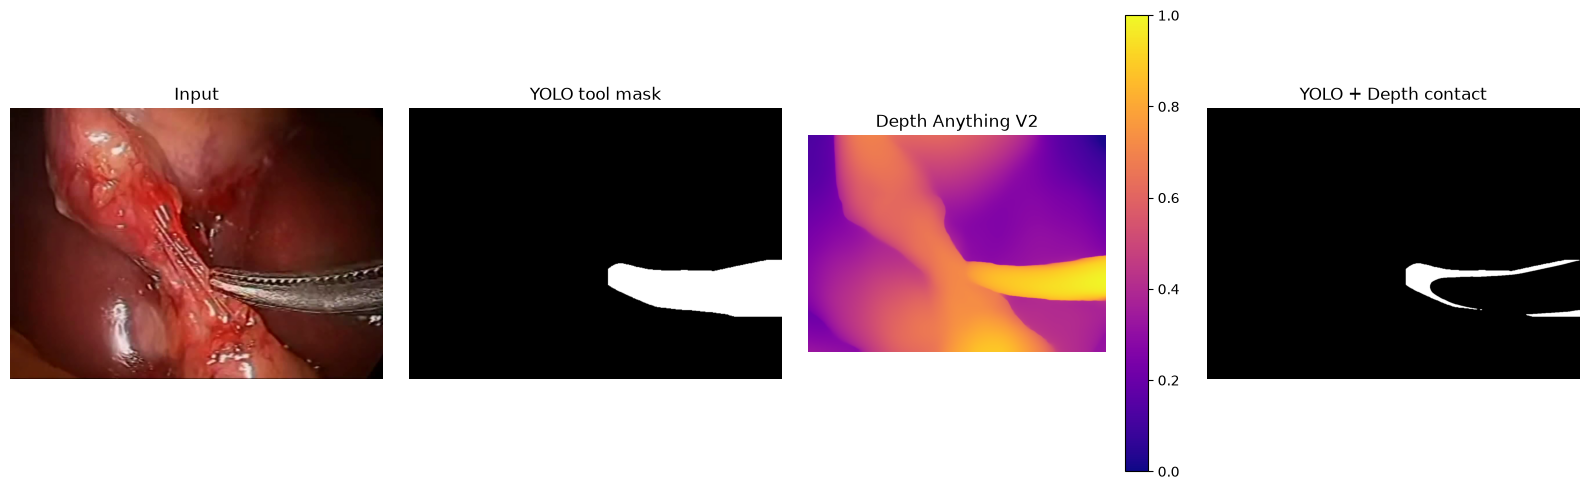

In [25]:
image_rgb = cv2.cvtColor(
    image_bgr,
    cv2.COLOR_BGR2RGB,
)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(
    yolo_tool_mask,
    cmap="gray",
)
plt.title("YOLO tool mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(
    depth_normalized,
    cmap="plasma",
)
plt.title("Depth Anything V2")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 4, 4)
plt.imshow(
    yolo_contact_mask,
    cmap="gray",
)
plt.title("YOLO + Depth contact")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    DEPTH_OUTPUT_DIR
    / "depth_contact_overview.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# U-Net

The semantic segmentation of endoscopic images was performed using a U-Net network, originally proposed by Ronneberger et al. for biomedical image segmentation. The architecture was adapted to a multiclass problem by using an output layer with one channel for each class. During training, weighted cross-entropy and Dice loss were used to address class imbalance and improve the overlap between the predicted masks and the annotations.


### Dataset

In [4]:
# Relative paths to the folder from which the notebook is opened
CHECKPOINT_PATH = Path("checkpoints/unet_best.pth")
OUTPUT_DIR = Path("outputs/unet")

# Parameters
IMAGE_SIZE = 512
BATCH_SIZE = 2
NUM_WORKERS = 0
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
THRESHOLD = 0.5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Working directory:", Path.cwd())
print("Dataset root:", UNET_ROOT.resolve())
print("Dataset exists:", UNET_ROOT.exists())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nDataset folders:")
print("images/train:", (UNET_ROOT / "images" / "train").exists())
print("images/val:", (UNET_ROOT / "images" / "val").exists())
print("images/test:", (UNET_ROOT / "images" / "test").exists())
print("masks/train:", (UNET_ROOT / "masks" / "train").exists())
print("masks/val:", (UNET_ROOT / "masks" / "val").exists())
print("masks/test:", (UNET_ROOT / "masks" / "test").exists())

Working directory: /home/federico-ai-rob/Scrivania/AIRO/MR_project
Dataset root: /home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset
Dataset exists: True
Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU

Dataset folders:
images/train: True
images/val: True
images/test: True
masks/train: True
masks/val: True
masks/test: True


In [5]:
print("Contents of unet_dataset:")
for path in sorted(UNET_ROOT.iterdir()):
    print(path)

print("\nSubfolders of images:")
images_root = UNET_ROOT / "images"

if images_root.exists():
    for path in sorted(images_root.iterdir()):
        print(path, "directory:", path.is_dir())

print("\nSubfolders of masks:")
masks_root = UNET_ROOT / "masks"

if masks_root.exists():
    for path in sorted(masks_root.iterdir()):
        print(path, "directory:", path.is_dir())

print("\nNumber of files per folder:")
for root in [images_root, masks_root]:
    if root.exists():
        for split_dir in sorted(root.iterdir()):
            if split_dir.is_dir():
                files = [
                    p for p in split_dir.iterdir()
                    if p.is_file()
                ]
                print(f"{split_dir}: {len(files)} files")

Contents of unet_dataset:
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/images
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/masks
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/preview_masks
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/preview_tti_masks
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/tti_masks

Subfolders of images:
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/images/test directory: True
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/images/train directory: True
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/images/val directory: True

Subfolders of masks:
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/masks/test directory: True
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/masks/train directory: True
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/masks/val directory: True

Number of files per folder:
/home/fed

In [6]:
images_train_dir = UNET_ROOT / "images" / "train"
masks_train_dir = UNET_ROOT / "masks" / "train"

image_paths = sorted(
    list(images_train_dir.glob("*.png")) +
    list(images_train_dir.glob("*.jpg")) +
    list(images_train_dir.glob("*.jpeg"))
)

mask_paths = sorted(
    list(masks_train_dir.glob("*.png")) +
    list(masks_train_dir.glob("*.jpg")) +
    list(masks_train_dir.glob("*.jpeg"))
)

image_stems = {path.stem for path in image_paths}
mask_stems = {path.stem for path in mask_paths}

images_without_masks = sorted(image_stems - mask_stems)
masks_without_images = sorted(mask_stems - image_stems)

print("Number of images:", len(image_paths))
print("Number of masks:", len(mask_paths))

print("\nImages without a mask:")
print(images_without_masks)
print("Total:", len(images_without_masks))

print("\nMasks without an image:")
print(masks_without_images)
print("Total:", len(masks_without_images))

Number of images: 2880
Number of masks: 2880

Images without a mask:
[]
Total: 0

Masks without an image:
[]
Total: 0


In [7]:
def list_mask_paths(mask_dir):
    return sorted(
        list(mask_dir.glob("*.png")) +
        list(mask_dir.glob("*.jpg")) +
        list(mask_dir.glob("*.jpeg"))
    )

def inspect_mask_values(root, split):
    mask_dir = Path(root) / "masks" / split
    mask_paths = list_mask_paths(mask_dir)

    values_counter = Counter()
    formats = Counter()

    for mask_path in mask_paths:
        mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

        if mask is None:
            continue

        formats[mask.ndim] += 1

        if mask.ndim == 2:
            values, counts = np.unique(mask, return_counts=True)

            for value, count in zip(values, counts):
                values_counter[int(value)] += int(count)

        elif mask.ndim == 3:
            colors = np.unique(mask.reshape(-1, mask.shape[-1]), axis=0)

            for color in colors:
                values_counter[tuple(color.tolist())] += 1

    return values_counter, formats

for split in ["train", "val", "test"]:
    values_counter, formats = inspect_mask_values(UNET_ROOT, split)

    print(f"\n{split.upper()}")
    print("Formats:", formats)
    print("Values/colors present:")

    for value, count in list(values_counter.items())[:30]:
        print(value, "->", count)


TRAIN
Formats: Counter({2: 2880})
Values/colors present:
0 -> 2750990345
2 -> 55299667
7 -> 76448857
9 -> 5708761
10 -> 109400665
6 -> 6231004
3 -> 1509334
12 -> 4246945
1 -> 1804254
4 -> 8721443
8 -> 6309245
5 -> 27244

VAL
Formats: Counter({2: 760})
Values/colors present:
0 -> 668077449
2 -> 11101248
7 -> 19626408
10 -> 27494294
6 -> 1125181
12 -> 1358144
9 -> 2212148
4 -> 1506864
1 -> 614305
3 -> 500153
8 -> 694806

TEST
Formats: Counter({2: 182})
Values/colors present:
0 -> 160840604
2 -> 2815144
7 -> 4199767
10 -> 9388059
9 -> 273419
6 -> 366513
1 -> 114174
4 -> 541368


### Class mapping 

In [8]:
# Mapping from raw mask values to internal classes 0–11 (tools)
RAW_TOOL_TO_CLASS = {
    0: 0,   # background
    1: 1,
    2: 2,
    3: 3,
    4: 4,
    5: 5,
    6: 6,
    7: 7,
    8: 8,
    9: 9,
    10: 10,
    12: 11,
}

# Mapping from raw TTI mask values to TTI classes 12–20
# Adjust these values according to how your TTI masks are encoded
RAW_TTI_TO_CLASS = {
    1: 12,  # Unknown TTI
    2: 13,  # Coagulation
    3: 14,  # Other
    4: 15,  # Retract and grab
    5: 16,  # Blunt dissection
    6: 17,  # Energy- sharp dissection
    7: 18,  # Staple
    8: 19,  # Retract and push
    9: 20,  # Cut- sharp dissection
}

# Total number of classes (tools 0–11 + TTI 12–20)
NUM_CLASSES = 21

# Class names, aligned with YOLO
CLASS_NAMES = [
    "tool_0",              # 0
    "tool_1",              # 1
    "tool_2",              # 2
    "tool_3",              # 3
    "tool_4",              # 4
    "tool_5",              # 5
    "tool_6",              # 6
    "tool_7",              # 7
    "tool_8",              # 8
    "tool_9",              # 9
    "tool_10_UNUSED",      # 10
    "tool_11",             # 11
    "Unknown TTI",         # 12
    "Coagulation",         # 13
    "Other",               # 14
    "Retract and grab",    # 15
    "Blunt dissection",    # 16
    "Energy- sharp dissection",  # 17
    "Staple",              # 18
    "Retract and push",    # 19
    "Cut- sharp dissection",     # 20
]

print("NUM_CLASSES:", NUM_CLASSES)
print("RAW_TOOL_TO_CLASS:", RAW_TOOL_TO_CLASS)
print("RAW_TTI_TO_CLASS:", RAW_TTI_TO_CLASS)
print("CLASS_NAMES:", CLASS_NAMES)

NUM_CLASSES: 21
RAW_TOOL_TO_CLASS: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 12: 11}
RAW_TTI_TO_CLASS: {1: 12, 2: 13, 3: 14, 4: 15, 5: 16, 6: 17, 7: 18, 8: 19, 9: 20}
CLASS_NAMES: ['tool_0', 'tool_1', 'tool_2', 'tool_3', 'tool_4', 'tool_5', 'tool_6', 'tool_7', 'tool_8', 'tool_9', 'tool_10_UNUSED', 'tool_11', 'Unknown TTI', 'Coagulation', 'Other', 'Retract and grab', 'Blunt dissection', 'Energy- sharp dissection', 'Staple', 'Retract and push', 'Cut- sharp dissection']


In [9]:
def build_unet_weight_map(
    mask,
    class_weights,
    w0=5.0,
    sigma=5.0
):
    mask = mask.astype(np.int64)

    if isinstance(class_weights, torch.Tensor):
        class_weights = (class_weights.detach().cpu().numpy())

    weight_map = np.zeros(mask.shape, dtype=np.float32)

    for class_index in np.unique(mask):
        class_index = int(class_index)

        if 0 <= class_index < len(class_weights ):
            weight_map[mask == class_index] = class_weights[class_index]

    foreground_classes = [int(value) for value in np.unique(mask) if int(value) != 0]

    if len(foreground_classes) < 2:
        return weight_map

    distance_maps = []

    for class_index in foreground_classes:
        object_mask = mask == class_index

        distance_map = distance_transform_edt(~object_mask)

        distance_maps.append(distance_map)

    distances = np.stack(distance_maps, axis=0)

    distances = np.sort(distances, axis=0)

    d1 = distances[0]
    d2 = distances[1]

    separation_weight = (
        w0 *
        np.exp(
            -((d1 + d2) ** 2) /
            (2.0 * sigma ** 2)
        )
    )

    background_region = mask == 0

    weight_map += (separation_weight * background_region.astype(np.float32))

    return weight_map.astype(np.float32)

### Dataset and DataLoader

In [10]:
print("Dataset root:")
print(UNET_ROOT.resolve())

if not UNET_ROOT.exists():
    raise FileNotFoundError(f"Dataset not found: {UNET_ROOT.resolve()}")

for split in ["train", "val", "test"]:
    images_dir = UNET_ROOT / "images" / split
    masks_dir = UNET_ROOT / "masks" / split

    image_count = len(list(images_dir.glob("*"))) if images_dir.exists() else 0
    mask_count = len(list(masks_dir.glob("*"))) if masks_dir.exists() else 0

    print(
        f"{split}: "
        f"{image_count} images, "
        f"{mask_count} masks"
    )

Dataset root:
/home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset
train: 2880 images, 2880 masks
val: 760 images, 760 masks
test: 182 images, 182 masks


In [11]:
class UNetDataset(Dataset):
    def __init__(
        self,
        root,
        split,
        image_size=512,
        augment=False,
        class_weights=None,
        return_weight_map=False
    ):
        self.root = Path(root)
        self.split = split
        self.image_size = image_size
        self.augment = augment
        self.class_weights = class_weights
        self.return_weight_map = (return_weight_map)

        self.image_dir = self.root / "images" / split
        self.mask_dir = self.root / "masks" / split
        self.ttimask_dir = self.root / "tti_masks" / split

        if not self.image_dir.exists():
            raise FileNotFoundError(
                f"Image folder not found: "
                f"{self.image_dir.resolve()}"
            )

        if not self.mask_dir.exists():
            raise FileNotFoundError(
                f"Mask folder not found: "
                f"{self.mask_dir.resolve()}"
            )

        image_paths = sorted(
            list(self.image_dir.glob("*.png")) +
            list(self.image_dir.glob("*.jpg")) +
            list(self.image_dir.glob("*.jpeg"))
        )

        mask_paths = sorted(
            list(self.mask_dir.glob("*.png")) +
            list(self.mask_dir.glob("*.jpg")) +
            list(self.mask_dir.glob("*.jpeg"))
        )

        ttimask_paths = []
        if self.ttimask_dir.exists():
            ttimask_paths = sorted(
                list(self.ttimask_dir.glob("*.png")) +
                list(self.ttimask_dir.glob("*.jpg")) +
                list(self.ttimask_dir.glob("*.jpeg"))
            )

        mask_by_stem = {
            mask_path.stem: mask_path
            for mask_path in mask_paths
        }

        ttimask_by_stem = {
            ttimask_path.stem: ttimask_path
            for ttimask_path in ttimask_paths
        } if ttimask_paths else {}

        self.samples = []
        for image_path in image_paths:
            stem = image_path.stem
            if stem not in mask_by_stem:
                continue

            mask_path = mask_by_stem[stem]
            ttimask_path = ttimask_by_stem.get(stem, None)

            self.samples.append(
                (image_path, mask_path, ttimask_path)
            )

        if len(self.samples) == 0:
            raise RuntimeError(
                f"No valid pair found in "
                f"{self.image_dir.resolve()}"
            )

        if (self.return_weight_map and self.class_weights is None):
            raise ValueError(
                "class_weights is required "
                "when return_weight_map=True"
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, mask_path, ttimask_path = self.samples[idx]
        image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

        ttimask = None
        if ttimask_path and Path(ttimask_path).exists():
            ttimask = cv2.imread(str(ttimask_path), cv2.IMREAD_UNCHANGED)
            if ttimask.ndim == 3:
                ttimask = ttimask[:, :, 0]

        if image_bgr is None:
            raise RuntimeError(f"Image cannot be read: {image_path}")

        if mask is None:
            raise RuntimeError(f"Mask cannot be read: {mask_path}")

        if mask.ndim == 3:
            mask = mask[:, :, 0]

        image_bgr = cv2.resize(image_bgr, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask,(self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        if ttimask is not None:
            ttimask = cv2.resize(ttimask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)


        # Augmentation
        if self.augment:
            if random.random() < 0.5:
                image_bgr = np.fliplr(image_bgr).copy()
                mask = np.fliplr(mask).copy()
                if ttimask is not None:
                    ttimask = np.fliplr(ttimask).copy()

            if random.random() < 0.5:
                image_bgr = np.flipud(image_bgr).copy()
                mask = np.flipud(mask).copy()
                if ttimask is not None:
                    ttimask = np.flipud(ttimask).copy()

        target = np.zeros((self.image_size, self.image_size), dtype=np.int64)

        # 1) Tool map (classes 0–11)
        for raw_val, class_id in RAW_TOOL_TO_CLASS.items():
            target[mask == raw_val] = class_id

        # 2) TTI map (classes 12–20)
        if ttimask is not None:
            for raw_tti, class_id in RAW_TTI_TO_CLASS.items():
                target[ttimask == raw_tti] = class_id

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        image_rgb = (image_rgb.astype(np.float32) / 255.0)
        image_rgb = np.transpose(image_rgb, (2, 0, 1))

        unique_values = np.unique(target)
        invalid_values = unique_values[
            (unique_values < 0) |
            (unique_values >= NUM_CLASSES)  # NUM_CLASSES = 21
        ]

        if len(invalid_values) > 0:
            raise ValueError(
                f"Invalid values in mask "
                f"{mask_path.name}: "
                f"{invalid_values.tolist()}"
            )

        sample = {
            "image": torch.from_numpy(image_rgb).float(),
            "mask": torch.from_numpy(target).long(),
            "id": image_path.stem
        }

        if self.return_weight_map:
            weight_map = build_unet_weight_map(
                mask=target,
                class_weights=self.class_weights,
                w0=5.0,
                sigma=5.0
            )
            sample["weight_map"] = torch.from_numpy(weight_map).float()

        return sample

In [12]:
train_dataset_base = UNetDataset(
    root=UNET_ROOT,
    split="train",
    image_size=IMAGE_SIZE,
    augment=True,
    class_weights=None,
    return_weight_map=False
)

val_dataset = UNetDataset(
    root=UNET_ROOT,
    split="val",
    image_size=IMAGE_SIZE,
    augment=False,
    class_weights=None,
    return_weight_map=False
)

test_dataset = UNetDataset(
    root=UNET_ROOT,
    split="test",
    image_size=IMAGE_SIZE,
    augment=False,
    class_weights=None,
    return_weight_map=False
)

sample = train_dataset_base[0]

print("Image shape:", sample["image"].shape)
print("Mask shape:", sample["mask"].shape)
print("Image dtype:", sample["image"].dtype)
print("Mask dtype:", sample["mask"].dtype)
print("Mask classes:", torch.unique(sample["mask"]))
print("ID:", sample["id"])

Image shape: torch.Size([3, 512, 512])
Mask shape: torch.Size([512, 512])
Image dtype: torch.float32
Mask dtype: torch.int64
Mask classes: tensor([ 0,  2, 16])
ID: adnansetlc100004_frame000042


In [13]:
for split in ["train", "val", "test"]:
    ttimask_dir = UNET_ROOT / "tti_masks" / split
    print(f"{split}:")
    print(f"  ttimask_dir: {ttimask_dir}")
    print(f"  exists: {ttimask_dir.exists()}")
    if ttimask_dir.exists():
        files = list(ttimask_dir.glob("*.png")) + list(ttimask_dir.glob("*.jpg"))
        print(f"  files count: {len(files)}")
        if len(files) > 0:
            print(f"  first file: {files[0].name}")
    else:
        # Controlla se esiste una cartella simile
        parent = ttimask_dir.parent
        print(f"  parent contents: {[p.name for p in parent.iterdir()]}")

train:
  ttimask_dir: /home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/tti_masks/train
  exists: True
  files count: 2880
  first file: adnansetlc14010_frame000141.png
val:
  ttimask_dir: /home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/tti_masks/val
  exists: True
  files count: 760
  first file: cholec80video20008_frame000000.png
test:
  ttimask_dir: /home/federico-ai-rob/Scrivania/AIRO/MR_project/unet_dataset/tti_masks/test
  exists: True
  files count: 182
  first file: cholec80video42002_frame000124.png


In [14]:
train_loader = DataLoader(
    train_dataset_base,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Dataset and DataLoaders created successfully.")
print("Train samples:", len(train_dataset_base))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

batch = next(iter(train_loader))

print("\nImages shape:", batch["image"].shape)
print("Masks shape:", batch["mask"].shape)
print("Images dtype:", batch["image"].dtype)
print("Masks dtype:", batch["mask"].dtype)
print("Mask values:", torch.unique(batch["mask"]))
print("IDs:", batch["id"])

Dataset and DataLoaders created successfully.
Train samples: 2880
Validation samples: 760
Test samples: 182

Images shape: torch.Size([2, 3, 512, 512])
Masks shape: torch.Size([2, 512, 512])
Images dtype: torch.float32
Masks dtype: torch.int64
Mask values: tensor([ 0,  7,  9, 10, 15, 17])
IDs: ['adnansetlc119005_frame000110', 'm2ccai2016video88004_frame000001']


In [15]:
mapped_values = set()

for split_dataset in [train_dataset_base, val_dataset, test_dataset]:
    for index in range(len(split_dataset)):
        mask = split_dataset[index]["mask"]
        mapped_values.update(torch.unique(mask).tolist())

print("Internal classes present:", sorted(mapped_values))

expected_values = set(range(NUM_CLASSES))

print("Expected classes:", sorted(expected_values))
print("All classes valid:", mapped_values.issubset(expected_values))

Internal classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20]
Expected classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
All classes valid: True


In [16]:
def compute_mapped_distribution(dataset):
    counter = Counter()

    for index in range(len(dataset)):
        mask = dataset[index]["mask"].numpy()
        values, counts = np.unique(mask, return_counts=True)

        for value, count in zip(values, counts):
            counter[int(value)] += int(count)

    total_pixels = sum(counter.values())

    rows = []

    for class_index in range(NUM_CLASSES): 
        count = counter.get(class_index, 0)

        rows.append(
            {
                "class_index": class_index,
                "class_name": CLASS_NAMES[class_index],
                "pixels": count,
                "percentage": (
                    100.0 * count / total_pixels
                    if total_pixels > 0
                    else 0.0
                )
            }
        )

    return pd.DataFrame(rows)

### Class weighting

In [17]:
def get_foreground_classes(dataset):
    rows = []

    for index in tqdm(range(len(dataset)), desc=f"Checking {dataset.split}"):
        mask = dataset[index]["mask"].numpy()

        classes = sorted(int(value) for value in np.unique(mask) if value != 0)

        rows.append(
            {
                "id": dataset[index]["id"],
                "foreground_classes": classes,
                "num_foreground_classes": len(classes)
            }
        )

    return pd.DataFrame(rows)

train_object_classes = get_foreground_classes(train_dataset_base)
print(train_object_classes["num_foreground_classes"].value_counts().sort_index())

multi_class_images = (train_object_classes[train_object_classes["num_foreground_classes"] > 1])
print(multi_class_images.head(20).to_string(index=False))

Checking train: 100%|██████████| 2880/2880 [02:34<00:00, 18.59it/s]

num_foreground_classes
1    467
2    963
3    622
4    806
5     21
6      1
Name: count, dtype: int64
                          id foreground_classes  num_foreground_classes
adnansetlc100004_frame000042            [2, 16]                       2
adnansetlc100005_frame000000            [2, 16]                       2
adnansetlc100006_frame000071            [2, 16]                       2
adnansetlc100007_frame000113            [2, 16]                       2
 adnansetlc10004_frame000055            [2, 16]                       2
  adnansetlc1002_frame000000            [7, 15]                       2
  adnansetlc1002_frame000011         [2, 7, 15]                       3
  adnansetlc1002_frame000023     [2, 7, 15, 16]                       4
  adnansetlc1002_frame000035     [2, 7, 15, 16]                       4
  adnansetlc1002_frame000150     [2, 7, 15, 16]                       4
  adnansetlc1006_frame000090         [2, 7, 15]                       3
  adnansetlc1007_frame000026     

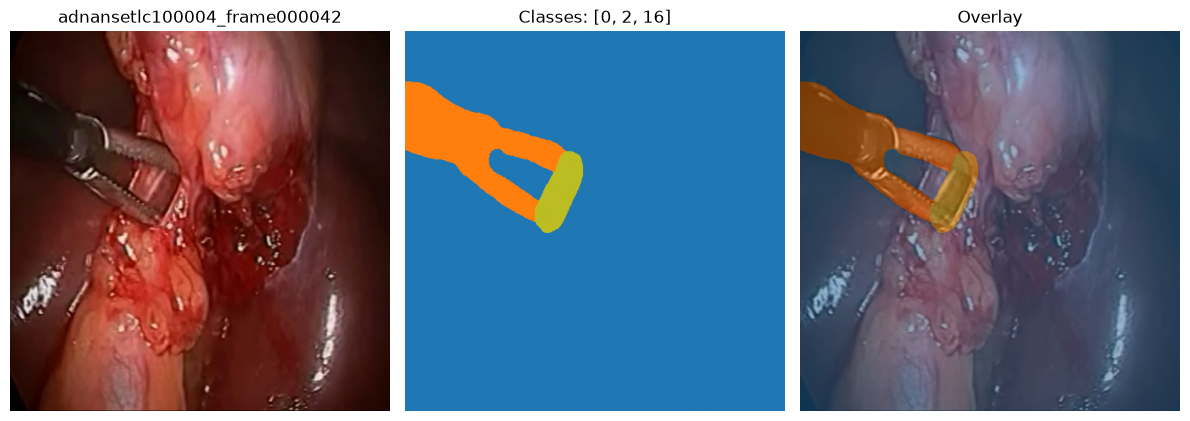

In [18]:
def show_sample_with_classes(dataset,index):
    sample = dataset[index]

    image = sample["image"].permute(1, 2, 0).numpy()

    mask = sample["mask"].numpy()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title(sample["id"])
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
    plt.title(f"Classes: {np.unique(mask).tolist()}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(image)
    plt.imshow(mask, cmap="tab20", alpha=0.45, vmin=0, vmax=NUM_CLASSES - 1)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

index = train_object_classes[train_object_classes["num_foreground_classes"] == 2].index[0]

show_sample_with_classes(train_dataset_base, index)

In [19]:
def compute_class_weights(dataset, num_classes, power=0.5, min_weight=0.1, max_weight=5.0):
    pixel_counts = np.zeros(num_classes, dtype=np.float64)

    for index in tqdm(range(len(dataset)), desc="Computing class weights"):
        mask = dataset[index]["mask"].numpy()
        values, counts = np.unique(mask, return_counts=True)

        for value, count in zip(values, counts):
            pixel_counts[int(value)] += int(count)

    valid_mask = pixel_counts > 0
    if not valid_mask.any():
        return pixel_counts, np.ones(num_classes, dtype=np.float64)

    raw_weights = np.zeros(num_classes, dtype=np.float64)
    raw_weights[valid_mask] = 1.0 / np.power(pixel_counts[valid_mask], power)

    median_weight = np.median(raw_weights[valid_mask])
    raw_weights[valid_mask] = raw_weights[valid_mask] / median_weight

    clipped_weights = np.clip(raw_weights, a_min=min_weight, a_max=max_weight)
    clipped_weights[~valid_mask] = max_weight

    return pixel_counts, clipped_weights

pixel_counts, class_weights_np = compute_class_weights(
    dataset=train_dataset_base,
    num_classes=NUM_CLASSES, 
    power=0.5,
    min_weight=0.1,
    max_weight=5.0
)

class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

weights_df = pd.DataFrame(
    {
        "class_index": list(range(NUM_CLASSES)),
        "class_name": CLASS_NAMES,
        "pixels": pixel_counts,
        "weight": class_weights_np
    }
)

print(weights_df.to_string(index=False))

Computing class weights: 100%|██████████| 2880/2880 [01:16<00:00, 37.63it/s]

 class_index               class_name      pixels   weight
           0                   tool_0 674230395.0 0.100000
           1                   tool_1    404760.0 1.667361
           2                   tool_2  11528335.0 0.312424
           3                   tool_3    328635.0 1.850425
           4                   tool_4   2110873.0 0.730125
           5                   tool_5     21534.0 5.000000
           6                   tool_6   1377759.0 0.903736
           7                   tool_7  13847762.0 0.285061
           8                   tool_8   1570919.0 0.846353
           9                   tool_9    936325.0 1.096264
          10           tool_10_UNUSED  29335980.0 0.195852
          11                  tool_11    891796.0 1.123300
          12              Unknown TTI    147763.0 2.759596
          13              Coagulation         0.0 5.000000
          14                    Other    639351.0 1.326657
          15         Retract and grab  11637976.0 0.3109

In [20]:
train_dataset = UNetDataset(
    root=UNET_ROOT,
    split="train",
    image_size=IMAGE_SIZE,
    augment=True,
    class_weights=class_weights_np,
    return_weight_map=True
)

def sample_weight_from_mask(dataset, index):
    mask = dataset[index]["mask"].numpy()

    foreground_classes = [
        int(value)
        for value in np.unique(mask)
        if value != 0
    ]

    if not foreground_classes:
        return 1.0

    class_weights_for_sampling = [
        1.0 / pixel_counts[class_index]
        for class_index in foreground_classes
    ]

    return max(class_weights_for_sampling)

sample_weights = np.array(
    [
        sample_weight_from_mask(
            train_dataset,
            index
        )
        for index in range(
            len(train_dataset)
        )
    ],
    dtype=np.float64
)

sample_weights = torch.tensor(sample_weights, dtype=torch.double)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

### U-Net model

In [21]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_ch,
                out_ch,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNetSmall(nn.Module):
    def __init__(self, in_channels=3, out_channels=21, base_channels=32):
        super().__init__()

        self.enc1 = DoubleConv(
            in_channels,
            base_channels
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(
            base_channels,
            base_channels * 2
        )
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(
            base_channels * 2,
            base_channels * 4
        )
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(
            base_channels * 4,
            base_channels * 8
        )

        self.up3 = nn.ConvTranspose2d(
            base_channels * 8,
            base_channels * 4,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            base_channels * 8,
            base_channels * 4
        )

        self.up2 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            base_channels * 4,
            base_channels * 2
        )

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            base_channels * 2,
            base_channels
        )

        # Multiclass output: one channel for each class
        self.head = nn.Conv2d(
            base_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.head(d1)

### Loss and metrics

In [22]:
class MulticlassDiceLoss(nn.Module):
    def __init__(
        self,
        num_classes,
        smooth=1.0,
        include_background=False
    ):
        super().__init__()

        self.num_classes = num_classes
        self.smooth = smooth
        self.include_background = (
            include_background
        )

    def forward(self, logits, targets):
        probabilities = torch.softmax(logits, dim=1)

        one_hot_targets = F.one_hot(targets, num_classes=self.num_classes)

        one_hot_targets = one_hot_targets.permute(0, 3, 1, 2).float()

        probabilities = probabilities.flatten(2)
        one_hot_targets = one_hot_targets.flatten(2)

        intersection = (probabilities * one_hot_targets).sum(dim=2)

        denominator = (probabilities.sum(dim=2) + one_hot_targets.sum(dim=2))

        dice = (
            2.0 * intersection +
            self.smooth
        ) / (
            denominator +
            self.smooth
        )

        target_area = (one_hot_targets.sum(dim=2))

        valid = target_area > 0

        if not self.include_background:
            valid[:, 0] = False

        dice_sum = (dice * valid.float()).sum(dim=1)

        valid_count = (valid.sum(dim=1)).clamp_min(1)

        dice_per_image = (dice_sum / valid_count)

        return 1.0 - dice_per_image.mean()


class MulticlassLoss(nn.Module):
    def __init__(
        self,
        num_classes,
        class_weights=None,
        ce_weight=0.5,
        dice_weight=0.5,
        label_smoothing=0.0
    ):
        super().__init__()

        self.class_weights = class_weights
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.label_smoothing = (
            label_smoothing
        )

        self.dice = MulticlassDiceLoss(
            num_classes=num_classes,
            include_background=False
        )

    def forward(
        self,
        logits,
        targets,
        weight_map=None
    ):
        ce_per_pixel = F.cross_entropy(
            logits,
            targets,
            weight=self.class_weights,
            reduction="none",
            label_smoothing=self.label_smoothing
        )

        if weight_map is not None:
            weight_map = weight_map.to(
                device=ce_per_pixel.device,
                dtype=ce_per_pixel.dtype
            )

            ce_loss = (ce_per_pixel * weight_map).sum() / weight_map.sum().clamp_min(1e-6)

        else:
            ce_loss = ce_per_pixel.mean()

        dice_loss = self.dice(logits, targets)

        return (self.ce_weight * ce_loss + self.dice_weight * dice_loss)


def multiclass_classification_metrics(logits, targets, num_classes, ignore_background=True):
    """
    Computes pixel-wise metrics for multiclass
    segmentation.

    Metrics are computed over pixels:
        target = ground-truth class
        prediction = predicted class

    Returns:
        accuracy
        precision_macro
        f1_macro
        precision_per_class
        f1_per_class
    """
    predictions = torch.argmax(logits, dim=1)

    y_true = targets.detach().cpu().numpy().reshape(-1)
    y_pred = predictions.detach().cpu().numpy().reshape(-1)

    all_labels = list(range(num_classes))

    if ignore_background:
        labels = list(range(1, num_classes))
    else:
        labels = all_labels

    accuracy = accuracy_score(y_true, y_pred)

    precision_per_class = precision_score(
        y_true,
        y_pred,
        labels=labels,
        average=None,
        zero_division=0
    )

    f1_per_class = f1_score(
        y_true,
        y_pred,
        labels=labels,
        average=None,
        zero_division=0
    )

    precision_macro = precision_score(
        y_true,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision_macro,
        "f1": f1_macro,
        "precision_per_class": precision_per_class,
        "f1_per_class": f1_per_class,
        "labels": labels
    }

In [23]:
def update_confusion_matrix(confusion_matrix, predictions, targets, num_classes):
    predictions = predictions.detach().view(-1).cpu()
    targets = targets.detach().view(-1).cpu()

    valid = ((targets >= 0) & (targets < num_classes))

    indices = (targets[valid] * num_classes + predictions[valid])

    counts = torch.bincount(indices, minlength=num_classes * num_classes)

    confusion_matrix += counts.reshape(num_classes, num_classes)

    return confusion_matrix

def metrics_from_confusion_matrix(confusion_matrix, ignore_background=True):
    cm = confusion_matrix.float()

    num_classes = cm.shape[0]

    true_positives = torch.diag(cm)

    false_positives = (cm.sum(dim=0) - true_positives)

    false_negatives = (cm.sum(dim=1) - true_positives)

    total_pixels = cm.sum().clamp_min(1.0)

    accuracy_all = (true_positives.sum() / total_pixels).item()

    if ignore_background:
        labels = list(range(1, num_classes))

        foreground_correct = (true_positives[1:].sum())

        foreground_total = (cm[1:, :].sum().clamp_min(1.0))

        accuracy_foreground = (
            foreground_correct /
            foreground_total
        ).item()
    else:
        labels = list(range(num_classes))
        accuracy_foreground = accuracy_all

    precision_per_class = []
    recall_per_class = []
    f1_per_class = []
    valid_labels = []

    for class_index in labels:
        target_support = (cm[class_index, :].sum())

        prediction_support = (cm[:, class_index].sum())

        if (target_support > 0 or prediction_support > 0):
            valid_labels.append(class_index)

    for class_index in labels:
        tp = true_positives[class_index]
        fp = false_positives[class_index]
        fn = false_negatives[class_index]

        precision_denominator = tp + fp
        recall_denominator = tp + fn
        f1_denominator = (2 * tp + fp + fn)

        precision = (
            tp / precision_denominator
            if precision_denominator > 0
            else torch.tensor(0.0)
        )

        recall = (
            tp / recall_denominator
            if recall_denominator > 0
            else torch.tensor(0.0)
        )

        f1 = (
            2 * tp / f1_denominator
            if f1_denominator > 0
            else torch.tensor(0.0)
        )

        precision_per_class.append(precision)

        recall_per_class.append(recall)

        f1_per_class.append(f1)

    precision_per_class = torch.stack(precision_per_class)

    recall_per_class = torch.stack(recall_per_class)

    f1_per_class = torch.stack(f1_per_class)

    return {
        "accuracy_all": accuracy_all,
        "accuracy_foreground": (
            accuracy_foreground
        ),
        "balanced_accuracy": (
            recall_per_class.mean().item()
        ),
        "precision": (
            precision_per_class.mean().item()
        ),
        "recall": (
            recall_per_class.mean().item()
        ),
        "f1": (
            f1_per_class.mean().item()
        ),
        "precision_per_class": (
            precision_per_class.numpy()
        ),
        "recall_per_class": (
            recall_per_class.numpy()
        ),
        "f1_per_class": (
            f1_per_class.numpy()
        ),
        "labels": valid_labels,
        "confusion_matrix": cm
    }

def collect_predictions(model, loader, device):
    model.eval()

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for batch in tqdm(
            loader,
            desc="Collecting predictions",
            unit="batch"
        ):
            images = batch["image"].to(
                device,
                non_blocking=True
            )

            masks = batch["mask"].to(
                device,
                non_blocking=True
            )

            logits = model(images)

            predictions = torch.argmax(logits, dim=1)

            all_targets.append(masks.cpu().numpy().reshape(-1))

            all_predictions.append(predictions.cpu().numpy().reshape(-1))

    y_true = np.concatenate(all_targets)

    y_pred = np.concatenate(all_predictions)

    return y_true, y_pred

### Training

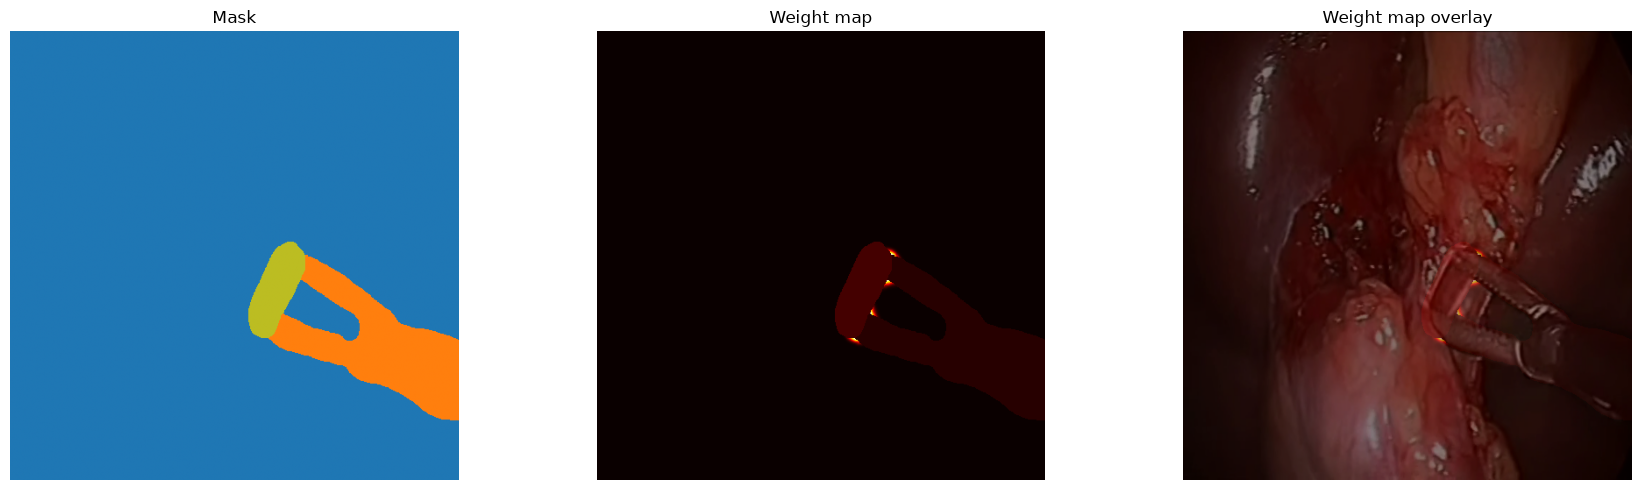

In [24]:
sample = train_dataset[0]

mask = sample["mask"].numpy()
weight_map = sample["weight_map"].numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(mask, cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
axes[0].set_title("Mask")

axes[1].imshow(weight_map, cmap="hot")
axes[1].set_title("Weight map")

axes[2].imshow(sample["image"].permute(1, 2, 0).numpy())
axes[2].imshow(weight_map, cmap="hot", alpha=0.5)
axes[2].set_title("Weight map overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
def run_epoch(model, loader, criterion, device, num_classes, optimizer=None, epoch=None, phase="train"):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0

    confusion_matrix = torch.zeros(
        num_classes,
        num_classes,
        dtype=torch.int64
    )

    progress_bar = tqdm(
        loader,
        desc=(
            f"Epoch {epoch:03d} {phase}"
            if epoch is not None
            else phase
        ),
        unit="batch",
        leave=False
    )

    for batch in progress_bar:
        batch_images = batch["image"].to(device, non_blocking=True)

        batch_masks = batch["mask"].to(device, non_blocking=True)

        batch_weight_map = batch.get("weight_map")

        if batch_weight_map is not None:
            batch_weight_map = batch_weight_map.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(batch_images)

            loss = criterion(
                logits,
                batch_masks,
                weight_map=batch_weight_map
            )

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = torch.argmax(logits.detach(), dim=1)

        confusion_matrix = update_confusion_matrix(
            confusion_matrix,
            predictions,
            batch_masks,
            num_classes
        )

        total_loss += loss.item()

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

        del logits
        del predictions
        del batch_images
        del batch_masks

        if batch_weight_map is not None:
            del batch_weight_map

    metrics = metrics_from_confusion_matrix(
        confusion_matrix,
        ignore_background=True
    )

    return {
        "loss": total_loss / len(loader),

        "accuracy": metrics["accuracy_all"],
        "accuracy_all": metrics["accuracy_all"],
        "accuracy_foreground": (
            metrics["accuracy_foreground"]
        ),
        "balanced_accuracy": (
            metrics["balanced_accuracy"]
        ),
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],

        "precision_per_class": (
            metrics["precision_per_class"]
        ),
        "recall_per_class": (
            metrics["recall_per_class"]
        ),
        "f1_per_class": (
            metrics["f1_per_class"]
        ),
        "labels": metrics["labels"],
        "confusion_matrix": (
            metrics["confusion_matrix"]
        )
    }

In [26]:
model = UNetSmall(
    in_channels=3,
    out_channels=NUM_CLASSES,
    base_channels=32
).to(DEVICE)

criterion = MulticlassLoss(
    num_classes=NUM_CLASSES,
    class_weights=class_weights,
    ce_weight=0.5,
    dice_weight=0.5,
    label_smoothing=0.0
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

num_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Model initialized.")
print("Device:", next(model.parameters()).device)
print("Trainable parameters:", num_parameters)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Model initialized.
Device: cuda:0
Trainable parameters: 1927669
Learning rate: 0.0001


In [27]:
batch = next(iter(train_loader))

with torch.no_grad():
    logits = model(batch["image"].to(DEVICE))

print("Logits shape:", logits.shape)

Logits shape: torch.Size([2, 21, 512, 512])


In [28]:
CHECKPOINT_PATH = Path(
    "checkpoints/unet_multiclass_weighted_best_f1.pth"
)

CHECKPOINT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

EARLY_STOPPING_PATIENCE = 7
MIN_DELTA = 1e-4
MIN_EPOCHS = 10

best_val_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0

history = []

best_val_precision_per_class = None
best_val_recall_per_class = None
best_val_f1_per_class = None
best_val_labels = None

print("Training U-Net multiclass")

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        device=DEVICE,
        num_classes=NUM_CLASSES,
        optimizer=optimizer,
        epoch=epoch,
        phase="train"
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    with torch.no_grad():
        val_metrics = run_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE,
            num_classes=NUM_CLASSES,
            optimizer=None,
            epoch=epoch,
            phase="val"
        )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    scheduler.step(
        val_metrics["f1"]
    )

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_result = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy_all"],
        "train_accuracy_foreground": (
            train_metrics["accuracy_foreground"]
        ),
        "train_balanced_accuracy": (
            train_metrics["balanced_accuracy"]
        ),
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy_all"],
        "val_accuracy_foreground": (
            val_metrics["accuracy_foreground"]
        ),
        "val_balanced_accuracy": (
            val_metrics["balanced_accuracy"]
        ),
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "lr": current_lr
    }

    history.append(epoch_result)

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"train loss: {train_metrics['loss']:.4f} | "
        f"train acc all: {train_metrics['accuracy_all']:.4f} | "
        f"train acc fg: {train_metrics['accuracy_foreground']:.4f} | "
        f"train precision: {train_metrics['precision']:.4f} | "
        f"train recall: {train_metrics['recall']:.4f} | "
        f"train F1: {train_metrics['f1']:.4f} | "
        f"val loss: {val_metrics['loss']:.4f} | "
        f"val acc all: {val_metrics['accuracy_all']:.4f} | "
        f"val acc fg: {val_metrics['accuracy_foreground']:.4f} | "
        f"val precision: {val_metrics['precision']:.4f} | "
        f"val recall: {val_metrics['recall']:.4f} | "
        f"val F1: {val_metrics['f1']:.4f} | "
        f"lr: {current_lr:.2e}"
    )

    improvement = (val_metrics["f1"] > best_val_f1 + MIN_DELTA)

    if improvement:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        epochs_without_improvement = 0

        best_val_precision_per_class = (
            val_metrics["precision_per_class"].copy()
        )

        best_val_recall_per_class = (
            val_metrics["recall_per_class"].copy()
        )

        best_val_f1_per_class = (
            val_metrics["f1_per_class"].copy()
        )

        best_val_labels = list(
            val_metrics["labels"]
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),

                "val_accuracy": (
                    val_metrics["accuracy_all"]
                ),

                "val_accuracy_foreground": (
                    val_metrics["accuracy_foreground"]
                ),

                "val_balanced_accuracy": (
                    val_metrics["balanced_accuracy"]
                ),

                "val_precision": (
                    val_metrics["precision"]
                ),

                "val_recall": (
                    val_metrics["recall"]
                ),

                "val_f1": (
                    val_metrics["f1"]
                ),

                "precision_per_class": (
                    val_metrics["precision_per_class"]
                ),

                "recall_per_class": (
                    val_metrics["recall_per_class"]
                ),

                "f1_per_class": (
                    val_metrics["f1_per_class"]
                ),

                "labels": val_metrics.get(
                    "labels",
                    list(range(1, NUM_CLASSES))
                ),

                "num_classes": NUM_CLASSES,
                "class_names": CLASS_NAMES
            },
            CHECKPOINT_PATH
        )

        print("Best checkpoint saved:", CHECKPOINT_PATH)

    else:
        epochs_without_improvement += 1

        print(
            "No F1 improvement: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    stop_training = (
        epoch >= MIN_EPOCHS and
        epochs_without_improvement >=
        EARLY_STOPPING_PATIENCE
    )

    if stop_training:
        print("\nEarly stopping triggered.")

        print("Last epoch:", epoch)

        print("Best epoch:", best_epoch)

        print(
            f"Best validation F1: "
            f"{best_val_f1:.4f}"
        )

        break

    del train_metrics
    del val_metrics

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print(
    f"Best validation F1: "
    f"{best_val_f1:.4f}"
)

if best_val_precision_per_class is not None:
    print("Best validation precision per class:", best_val_precision_per_class)

if best_val_f1_per_class is not None:
    print("Best validation F1 per class:", best_val_f1_per_class)

if best_val_labels is not None:
    print("\nBest checkpoint metrics:")

    for position, class_index in enumerate(best_val_labels):
        print(
            f"{class_index} - "
            f"{CLASS_NAMES[class_index]} | "
            f"precision: "
            f"{best_val_precision_per_class[position]:.4f} | "
            f"recall: "
            f"{best_val_recall_per_class[position]:.4f} | "
            f"F1: "
            f"{best_val_f1_per_class[position]:.4f}"
        )

Training U-Net multiclass


Epoch 001/50 | train loss: 1.5833 | train acc all: 0.0406 | train acc fg: 0.1012 | train precision: 0.0088 | train recall: 0.1728 | train F1: 0.0112 | val loss: 0.6995 | val acc all: 0.0736 | val acc fg: 0.0047 | val precision: 0.0049 | val recall: 0.0719 | val F1: 0.0006 | lr: 1.00e-04
Best checkpoint saved: checkpoints/unet_multiclass_weighted_best_f1.pth


Epoch 002/50 | train loss: 1.2643 | train acc all: 0.1507 | train acc fg: 0.1393 | train precision: 0.0328 | train recall: 0.2292 | train F1: 0.0139 | val loss: 0.6817 | val acc all: 0.1407 | val acc fg: 0.0059 | val precision: 0.0050 | val recall: 0.0607 | val F1: 0.0016 | lr: 1.00e-04
Best checkpoint saved: checkpoints/unet_multiclass_weighted_best_f1.pth


Epoch 003/50 | train loss: 1.1285 | train acc all: 0.2795 | train acc fg: 0.1815 | train precision: 0.0462 | train recall: 0.2613 | train F1: 0.0276 | val loss: 0.6679 | val acc all: 0.2542 | val acc fg: 0.0110 | val precision: 0.0016 | val recall: 0.1036 | val F1: 0.0029 | lr: 1.00e-04
Best checkpoint saved: checkpoints/unet_multiclass_weighted_best_f1.pth


Epoch 004/50 | train loss: 1.0536 | train acc all: 0.4256 | train acc fg: 0.1840 | train precision: 0.0953 | train recall: 0.2818 | train F1: 0.0419 | val loss: 0.6458 | val acc all: 0.4107 | val acc fg: 0.0112 | val precision: 0.0026 | val recall: 0.0882 | val F1: 0.0038 | lr: 1.00e-04
Best checkpoint saved: checkpoints/unet_multiclass_weighted_best_f1.pth


...

Epoch 046/50 | train loss: 0.3369 | train acc all: 0.8718 | train acc fg: 0.6823 | train precision: 0.4162 | train recall: 0.6870 | train F1: 0.4854 | val loss: 0.4232 | val acc all: 0.8125 | val acc fg: 0.3922 | val precision: 0.1018 | val recall: 0.2109 | val F1: 0.1110 | lr: 2.50e-05
No F1 improvement: 1/7


Epoch 047/50 | train loss: 0.3369 | train acc all: 0.8729 | train acc fg: 0.6854 | train precision: 0.4176 | train recall: 0.6939 | train F1: 0.4894 | val loss: 0.4229 | val acc all: 0.8281 | val acc fg: 0.3676 | val precision: 0.1090 | val recall: 0.2058 | val F1: 0.1152 | lr: 2.50e-05
Best checkpoint saved: checkpoints/unet_multiclass_weighted_best_f1.pth


Epoch 048/50 | train loss: 0.3384 | train acc all: 0.8707 | train acc fg: 0.6745 | train precision: 0.4142 | train recall: 0.6866 | train F1: 0.4839 | val loss: 0.4136 | val acc all: 0.8221 | val acc fg: 0.4341 | val precision: 0.1018 | val recall: 0.2115 | val F1: 0.1172 | lr: 2.50e-05
Best checkpoint saved: checkpoints/unet_multiclass_weighted_best_f1.pth


Epoch 049/50 | train loss: 0.3367 | train acc all: 0.8724 | train acc fg: 0.6835 | train precision: 0.4184 | train recall: 0.6939 | train F1: 0.4909 | val loss: 0.4170 | val acc all: 0.8287 | val acc fg: 0.3974 | val precision: 0.1124 | val recall: 0.2044 | val F1: 0.1175 | lr: 2.50e-05
Best checkpoint saved: checkpoints/unet_multiclass_weighted_best_f1.pth


Epoch 050/50 | train loss: 0.3214 | train acc all: 0.8769 | train acc fg: 0.6983 | train precision: 0.4312 | train recall: 0.6970 | train F1: 0.5011 | val loss: 0.4149 | val acc all: 0.8538 | val acc fg: 0.3945 | val precision: 0.1174 | val recall: 0.1984 | val F1: 0.1229 | lr: 2.50e-05
Best checkpoint saved: checkpoints/unet_multiclass_weighted_best_f1.pth

Training completed.
Best epoch: 50
Best validation F1: 0.1229
Best validation precision per class: [  0.0070016     0.30605    0.091426     0.15552           0     0.18869       0.392     0.02002    0.026802     0.57738    0.050077  1.1309e-05           0    0.013557     0.37926    0.054305    0.083071           0   0.0022148           0]
Best validation F1 per class: [    0.01136     0.21216     0.15199     0.23164           0     0.20559      0.3301     0.03764    0.048929     0.59272    0.085862   2.167e-05           0    0.025812     0.35578     0.04677     0.11762           0   0.0036119           0]

Best checkpoint metrics:


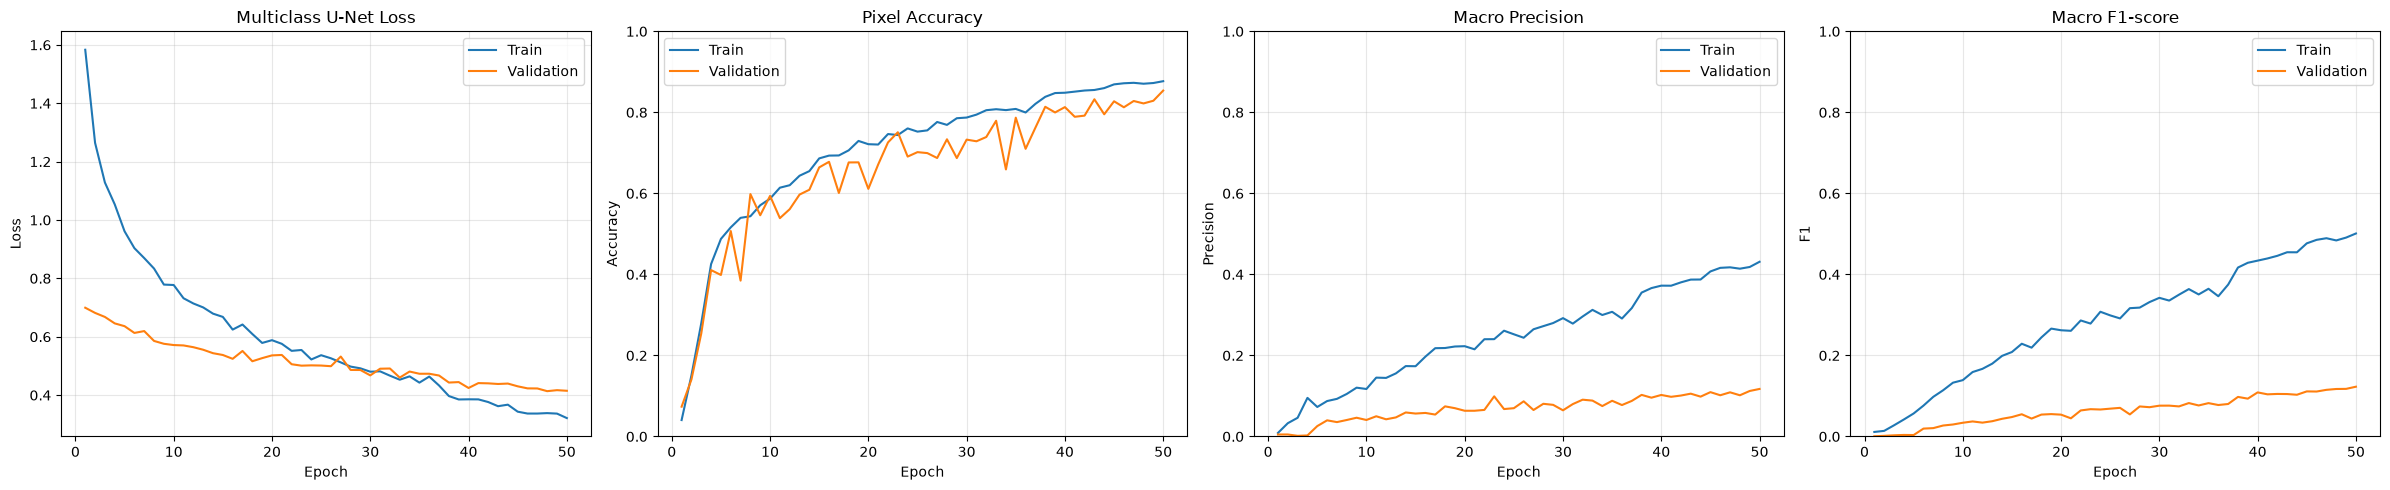

In [29]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train"
)

axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation"
)

axes[0].set_title("Multiclass U-Net Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train"
)

axes[1].plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation"
)

axes[1].set_title("Pixel Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(
    history_df["epoch"],
    history_df["train_precision"],
    label="Train"
)

axes[2].plot(
    history_df["epoch"],
    history_df["val_precision"],
    label="Validation"
)

axes[2].set_title("Macro Precision")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Precision")
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)
axes[2].legend()

axes[3].plot(
    history_df["epoch"],
    history_df["train_f1"],
    label="Train"
)

axes[3].plot(
    history_df["epoch"],
    history_df["val_f1"],
    label="Validation"
)

axes[3].set_title("Macro F1-score")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("F1")
axes[3].set_ylim(0, 1)
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

In [30]:
best_model = UNetSmall(
    in_channels=3,
    out_channels=NUM_CLASSES,
    base_channels=32
).to(DEVICE)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

best_model.load_state_dict(checkpoint["model_state_dict"])

best_model.eval()

print("Best checkpoint loaded.")
print("Checkpoint:", CHECKPOINT_PATH.resolve())
print("Epoch:", checkpoint["epoch"])
print("Validation accuracy:", checkpoint["val_accuracy"])
print("Validation precision:", checkpoint["val_precision"]) 
print("Validation F1:", checkpoint["val_f1"])

Best checkpoint loaded.
Checkpoint: /home/federico-ai-rob/Scrivania/AIRO/MR_project/checkpoints/unet_multiclass_weighted_best_f1.pth
Epoch: 50
Validation accuracy: 0.8537881374359131
Validation precision: 0.11736905574798584
Validation F1: 0.12288083881139755


Confusion matrix shape: (21, 21)


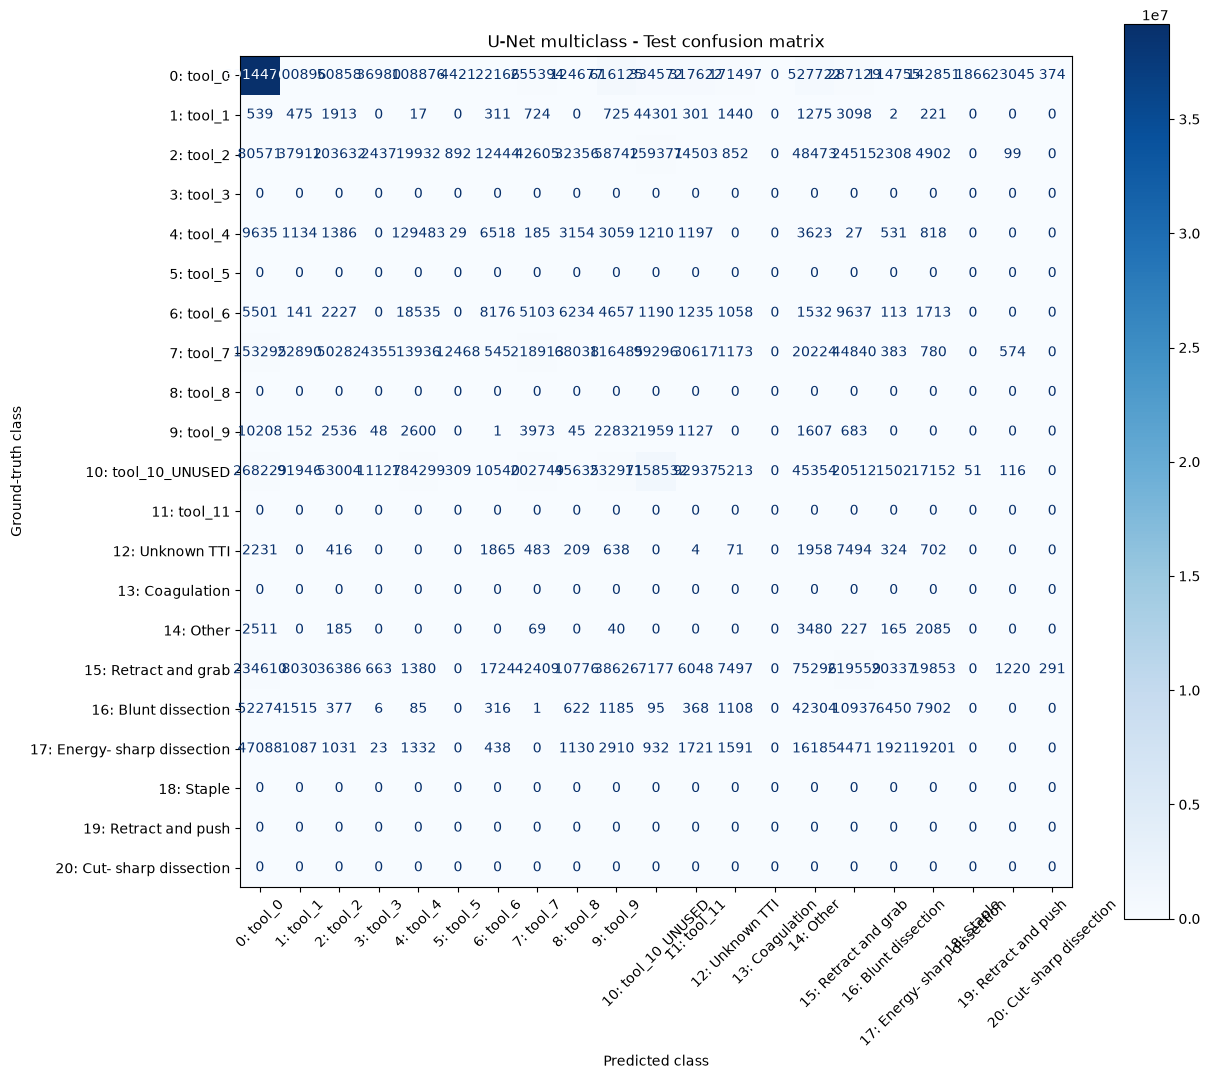

In [31]:
y_true_test, y_pred_test = collect_predictions(
    model=best_model,
    loader=test_loader,
    device=DEVICE
)

labels = list(range(NUM_CLASSES))

test_confusion_matrix = confusion_matrix(
    y_true_test,
    y_pred_test,
    labels=labels
)

print("Confusion matrix shape:", test_confusion_matrix.shape)

display_labels = [
    f"{index}: {CLASS_NAMES[index]}"
    for index in labels
]

fig_absolute, ax_absolute = plt.subplots(figsize=(13, 11))

display_absolute = ConfusionMatrixDisplay(confusion_matrix=test_confusion_matrix, display_labels=display_labels)

display_absolute.plot(
    ax=ax_absolute,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
    colorbar=True
)

ax_absolute.set_title(
    "U-Net multiclass - "
    "Test confusion matrix"
)

ax_absolute.set_xlabel("Predicted class")

ax_absolute.set_ylabel("Ground-truth class")

plt.tight_layout()
plt.show()

### Results

In [32]:
test_metrics = run_epoch(
    model=best_model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES,
    optimizer=None,
    phase="test"
)

print("Test accuracy:", test_metrics["accuracy_all"])
print("Test foreground accuracy:", test_metrics["accuracy_foreground"])
print("Test balanced accuracy:", test_metrics["balanced_accuracy"])
print("Test precision:",  test_metrics["precision"])
print("Test recall:", test_metrics["recall"])
print("Test F1:", test_metrics["f1"])

Test accuracy: 0.8601004481315613
Test foreground accuracy: 0.3551728129386902
Test balanced accuracy: 0.16132685542106628
Test precision: 0.10826008021831512
Test recall: 0.16132685542106628
Test F1: 0.10432642698287964


In [33]:
for class_index, (
    precision_value,
    f1_value
) in enumerate(
    zip(
        test_metrics["precision_per_class"],
        test_metrics["f1_per_class"]
    ),
    start=1
):
    class_name = (
        CLASS_NAMES[class_index]
        if class_index < len(CLASS_NAMES)
        else f"class_{class_index}"
    )

    print(
        f"{class_index} - {class_name}: "
        f"precision={precision_value:.4f}, "
        f"F1={f1_value:.4f}"
    )

1 - tool_1: precision=0.0018, F1=0.0030
2 - tool_2: precision=0.3406, F1=0.2051
3 - tool_3: precision=0.0000, F1=0.0000
4 - tool_4: precision=0.2695, F1=0.4031
5 - tool_5: precision=0.0000, F1=0.0000
6 - tool_6: precision=0.1257, F1=0.1238
7 - tool_7: precision=0.2833, F1=0.2683
8 - tool_8: precision=0.0000, F1=0.0000
9 - tool_9: precision=0.0208, F1=0.0398
10 - tool_10_UNUSED: precision=0.6406, F1=0.5451
11 - tool_11: precision=0.0000, F1=0.0000
12 - Unknown TTI: precision=0.0004, F1=0.0007
13 - Coagulation: precision=0.0000, F1=0.0000
14 - Other: precision=0.0044, F1=0.0087
15 - Retract and grab: precision=0.3468, F1=0.3217
16 - Blunt dissection: precision=0.0433, F1=0.0470
17 - Energy- sharp dissection: precision=0.0880, F1=0.1203
18 - Staple: precision=0.0000, F1=0.0000
19 - Retract and push: precision=0.0000, F1=0.0000
20 - Cut- sharp dissection: precision=0.0000, F1=0.0000


In [34]:
def extract_instances_from_mask(
    class_mask,
    min_area=50
):
    """
    Extracts separate instances from the multiclass mask.

    Returns a list of dictionaries:
        class_index
        instance_id
        mask
        bbox
        area
    """
    instances = []

    class_values = np.unique(class_mask)

    for class_index in class_values:
        class_index = int(class_index)

        if class_index == 0:
            continue

        binary_class_mask = (class_mask == class_index).astype(np.uint8)

        num_labels, labels, stats, _ = (
            cv2.connectedComponentsWithStats(
                binary_class_mask,
                connectivity=8
            )
        )

        instance_id = 0

        for label_id in range(1, num_labels):
            area = stats[label_id, cv2.CC_STAT_AREA]

            if area < min_area:
                continue

            x = stats[label_id, cv2.CC_STAT_LEFT]

            y = stats[label_id, cv2.CC_STAT_TOP]

            width = stats[label_id, cv2.CC_STAT_WIDTH]

            height = stats[label_id, cv2.CC_STAT_HEIGHT]

            instance_mask = (labels == label_id)

            instances.append(
                {
                    "class_index": class_index,
                    "instance_id": instance_id,
                    "mask": instance_mask,
                    "bbox": (
                        int(x),
                        int(y),
                        int(width),
                        int(height)
                    ),
                    "area": int(area)
                }
            )

            instance_id += 1

    return instances

In [35]:
sample = test_dataset[0]

ground_truth = sample["mask"].numpy()

ground_truth_instances = (
    extract_instances_from_mask(
        ground_truth,
        min_area=50
    )
)

for instance in ground_truth_instances:
    print(
        "Class:",
        instance["class_index"],
        "BBox:",
        instance["bbox"],
        "Area:",
        instance["area"]
    )

Class: 2 BBox: (275, 288, 237, 104) Area: 17329


In [36]:
@torch.no_grad()
def show_multiclass_prediction(
    model,
    dataset,
    index=0,
    class_names=None
):
    model.eval()

    sample = dataset[index]

    image = sample["image"].unsqueeze(0).to(DEVICE)
    ground_truth = sample["mask"].cpu().numpy()

    logits = model(image)

    probabilities = torch.softmax(logits, dim=1)

    prediction = torch.argmax(probabilities, dim=1)[0].cpu().numpy()

    predicted_instances = (
        extract_instances_from_mask(
            prediction,
            min_area=100
        )
    )

    for instance in predicted_instances:
        print(
            "Class:",
            instance["class_index"],
            "Bounding box:",
            instance["bbox"],
            "Area:",
            instance["area"]
        )

    image_rgb = sample["image"].permute(1, 2, 0).cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(image_rgb)
    axes[0].set_title("Input")

    axes[1].imshow(
        ground_truth,
        cmap="tab20",
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    axes[1].set_title("Ground truth")

    axes[2].imshow(
        prediction,
        cmap="tab20",
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    axes[2].set_title("Multiclass prediction")

    axes[3].imshow(image_rgb)
    axes[3].imshow(
        prediction,
        cmap="tab20",
        alpha=0.45,
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    axes[3].set_title("Prediction overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print("Sample ID:", sample["id"])
    print("Ground-truth classes:", np.unique(ground_truth))
    print("Predicted classes:", np.unique(prediction))

    for class_index in range(NUM_CLASSES):
        gt_area = np.mean(ground_truth == class_index)

        predicted_area = np.mean(prediction == class_index)

        class_name = (
            class_names[class_index]
            if class_names is not None
            else f"class_{class_index}"
        )

        print(
            f"{class_name}: "
            f"GT={gt_area:.4f}, "
            f"Pred={predicted_area:.4f}"
        )

Class: 1 Bounding box: (146, 404, 14, 14) Area: 109
Class: 4 Bounding box: (133, 437, 36, 43) Area: 677
Class: 5 Bounding box: (380, 362, 72, 31) Area: 998
Class: 6 Bounding box: (323, 310, 50, 28) Area: 460
Class: 7 Bounding box: (330, 287, 182, 122) Area: 9791
Class: 7 Bounding box: (301, 306, 35, 13) Area: 274
Class: 7 Bounding box: (337, 310, 17, 10) Area: 106
Class: 9 Bounding box: (341, 307, 90, 18) Area: 683
Class: 10 Bounding box: (152, 426, 12, 24) Area: 177
Class: 11 Bounding box: (146, 432, 14, 25) Area: 179
Class: 14 Bounding box: (253, 327, 82, 64) Area: 2779
Class: 14 Bounding box: (145, 352, 55, 51) Area: 2235
Class: 14 Bounding box: (310, 459, 44, 49) Area: 1076
Class: 15 Bounding box: (285, 305, 53, 29) Area: 702
Class: 15 Bounding box: (418, 313, 92, 91) Area: 2813
Class: 15 Bounding box: (325, 342, 10, 25) Area: 141
Class: 16 Bounding box: (258, 308, 34, 37) Area: 441
Class: 16 Bounding box: (305, 415, 21, 25) Area: 192


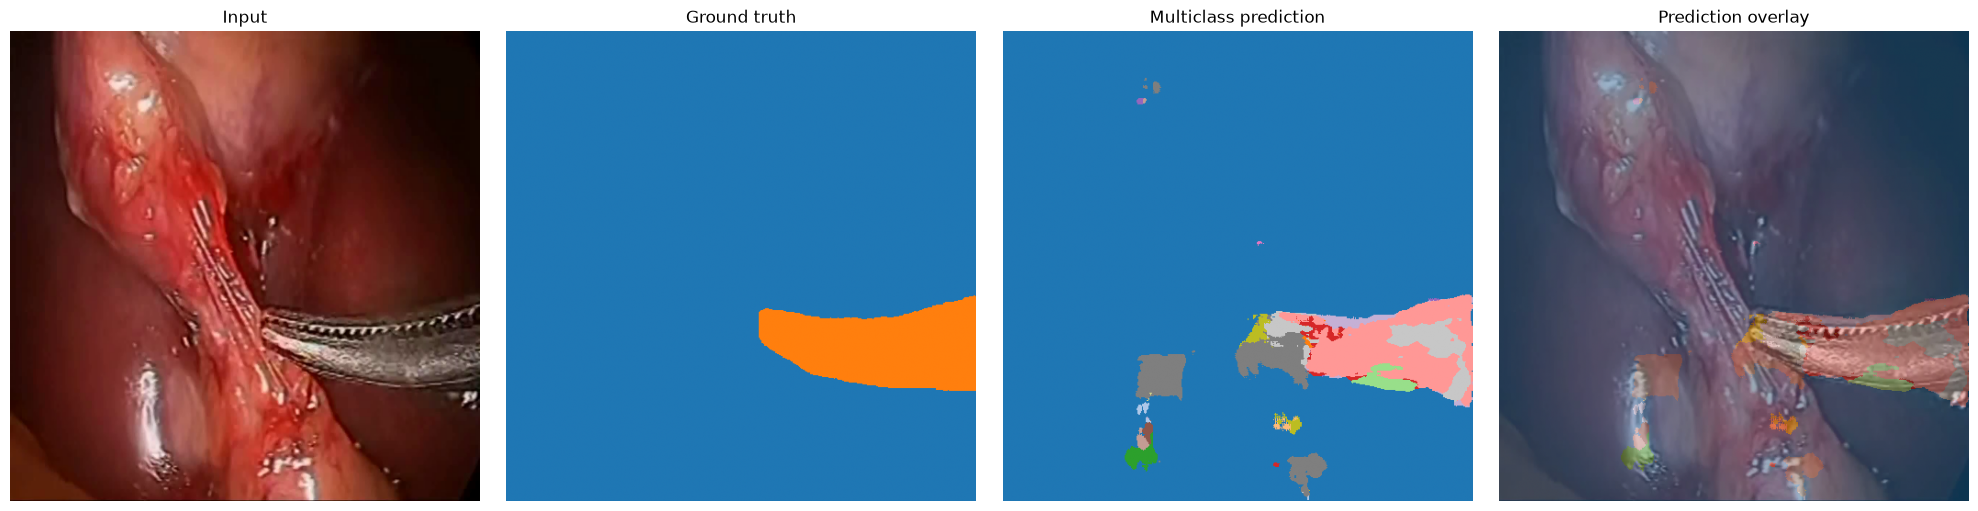

Sample ID: adnansetlc100009_frame000000
Ground-truth classes: [0 2]
Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 14 15 16 17]
tool_0: GT=0.9339, Pred=0.9044
tool_1: GT=0.0000, Pred=0.0005
tool_2: GT=0.0661, Pred=0.0003
tool_3: GT=0.0000, Pred=0.0005
tool_4: GT=0.0000, Pred=0.0026
tool_5: GT=0.0000, Pred=0.0038
tool_6: GT=0.0000, Pred=0.0027
tool_7: GT=0.0000, Pred=0.0390
tool_8: GT=0.0000, Pred=0.0003
tool_9: GT=0.0000, Pred=0.0032
tool_10_UNUSED: GT=0.0000, Pred=0.0007
tool_11: GT=0.0000, Pred=0.0008
Unknown TTI: GT=0.0000, Pred=0.0001
Coagulation: GT=0.0000, Pred=0.0000
Other: GT=0.0000, Pred=0.0239
Retract and grab: GT=0.0000, Pred=0.0146
Blunt dissection: GT=0.0000, Pred=0.0027
Energy- sharp dissection: GT=0.0000, Pred=0.0000
Staple: GT=0.0000, Pred=0.0000
Retract and push: GT=0.0000, Pred=0.0000
Cut- sharp dissection: GT=0.0000, Pred=0.0000


In [37]:
show_multiclass_prediction(
    model=best_model,
    dataset=test_dataset,
    index=0,
    class_names=CLASS_NAMES
)

## Depth Anything v2

To obtain additional geometric information, Depth Anything V2 was integrated as a pretrained model for monocular depth estimation. The model receives an RGB image and returns a relative depth map. This map does not represent an absolute metric distance, but rather an estimate of the relative position of regions within the image. The depth map is restricted to the tool region identified by the U-Net and subsequently filtered using a quantile, producing a contact mask that is used as auxiliary information during post-processing.

In [38]:
for class_index, class_name in enumerate(CLASS_NAMES):
    print(class_index, "->", class_name)

0 -> tool_0
1 -> tool_1
2 -> tool_2
3 -> tool_3
4 -> tool_4
5 -> tool_5
6 -> tool_6
7 -> tool_7
8 -> tool_8
9 -> tool_9
10 -> tool_10_UNUSED
11 -> tool_11
12 -> Unknown TTI
13 -> Coagulation
14 -> Other
15 -> Retract and grab
16 -> Blunt dissection
17 -> Energy- sharp dissection
18 -> Staple
19 -> Retract and push
20 -> Cut- sharp dissection


In [39]:
DEPTH_MODEL_NAME = ("depth-anything/Depth-Anything-V2-Small-hf")

DEPTH_QUANTILE = 0.25
MIN_CONTACT_AREA = 20

TOOL_CLASS_INDICES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]  # tool classes (excluding background 0)
TTI_CLASS_INDICES = [12, 13, 14, 15, 16, 17, 18, 19, 20]  # TTI classes

# "low" selects the lowest depth values.
# "high" selects the highest depth values.
DEPTH_SELECTION = "high"

print("Depth model:", DEPTH_MODEL_NAME)

print("Depth quantile:", DEPTH_QUANTILE)

print("Min contact area:", MIN_CONTACT_AREA)

print("Tool classes:", TOOL_CLASS_INDICES)

print("Depth selection:", DEPTH_SELECTION)

Depth model: depth-anything/Depth-Anything-V2-Small-hf
Depth quantile: 0.25
Min contact area: 20
Tool classes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Depth selection: high


In [40]:
depth_pipe = pipeline(
    task="depth-estimation",
    model=DEPTH_MODEL_NAME,
    device=0 if torch.cuda.is_available() else -1
)

print("Depth Anything V2 loaded successfully.")

Loading weights: 100%|██████████| 287/287 [00:00<00:00, 15577.48it/s]


Depth Anything V2 loaded successfully.


### Preprocessing

In [41]:
def tensor_to_rgb_uint8(image_tensor):
    image_rgb = (
        image_tensor
        .detach()
        .cpu()
        .permute(1, 2, 0)
        .numpy()
    )

    image_rgb = np.clip(image_rgb * 255.0, 0, 255).astype(np.uint8)

    return image_rgb

def normalize_depth(depth):
    depth = np.asarray(depth, dtype=np.float32)

    finite_values = depth[np.isfinite(depth)]

    if finite_values.size == 0:
        return np.zeros_like(depth, dtype=np.float32)

    low = np.percentile(finite_values, 1.0)

    high = np.percentile(finite_values, 99.0)

    if high <= low:
        return np.zeros_like(
            depth,
            dtype=np.float32
        )

    depth = np.clip(depth, low, high)

    depth = (depth - low) / (high - low)

    return depth.astype(np.float32)

def estimate_depth(image_rgb, depth_pipe, target_size=None):
    """
    Returns a float32 depth map with the size
    target_size=(height, width).
    """

    image_pil = Image.fromarray(image_rgb)

    output = depth_pipe(image_pil)

    depth_map = None

    if "predicted_depth" in output:
        predicted_depth = output["predicted_depth"]

        if isinstance(predicted_depth, torch.Tensor):
            depth_map = (predicted_depth.detach().cpu().numpy())

        else:
            depth_map = np.asarray(predicted_depth, dtype=np.float32)

    elif "depth" in output:
        depth_map = np.asarray(output["depth"], dtype=np.float32)

    else:
        raise KeyError(
            "Depth Anything output does not contain "
            "'predicted_depth' or 'depth'. "
            f"Available keys: {output.keys()}"
        )

    depth_map = np.squeeze(depth_map).astype(np.float32)

    if target_size is None:
        target_size = (image_rgb.shape[0], image_rgb.shape[1])

    target_height, target_width = (target_size)

    if depth_map.shape != (target_height, target_width):
        depth_map = cv2.resize(
            depth_map,
            (target_width, target_height),
            interpolation=cv2.INTER_LINEAR
        )

    return depth_map

### Contact Mask

In [42]:
@torch.no_grad()
def predict_multiclass_mask(model, image_tensor, device=DEVICE):
    model.eval()

    image_input = (image_tensor.unsqueeze(0).to(device))

    logits = model(image_input)

    probabilities = torch.softmax(logits, dim=1)

    predicted_mask = torch.argmax(probabilities, dim=1)[0]

    predicted_mask = (predicted_mask.cpu().numpy().astype(np.int64))

    probabilities = (probabilities[0].cpu().numpy().astype(np.float32))

    return (predicted_mask, probabilities)

In [43]:
def make_tool_mask_from_multiclass(predicted_mask, tool_class_indices):
    tool_mask = np.isin(predicted_mask, tool_class_indices)

    return (tool_mask.astype(np.uint8) * 255)

def make_tti_mask_from_multiclass(predicted_mask, tti_class_indices):
    tti_mask = np.isin(predicted_mask, tti_class_indices)
    return (tti_mask.astype(np.uint8) * 255)

In [44]:
def keep_large_components(mask, min_area=20):
    if min_area <= 0:
        return mask

    binary_mask = (mask > 0).astype(np.uint8)

    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=8
        )
    )

    filtered = np.zeros_like(mask, dtype=np.uint8)

    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]

        if area >= min_area:
            filtered[labels == label_id] = 255

    return filtered

### tool + depth

In [45]:
def fuse_tool_depth_quantile(tool_mask, depth_map, quantile=0.25, min_area=20, selection="high"):
    """
    Selects a portion of the tool mask based on relative depth.

    selection="high":
        selects the highest depth values.

    selection="low":
        selects the lowest depth values.
    """

    depth_norm = normalize_depth(depth_map)

    tool_region = (tool_mask > 0)

    tool_depth_values = depth_norm[tool_region]

    if tool_depth_values.size == 0:
        return np.zeros_like(
            tool_mask,
            dtype=np.uint8
        )

    depth_cutoff = np.quantile(tool_depth_values, quantile)

    if selection == "high":
        contact_region = (tool_region & (depth_norm >= depth_cutoff))

    elif selection == "low":
        contact_region = (tool_region & (depth_norm <= depth_cutoff))

    else:
        raise ValueError(
            "selection must be 'high' "
            "or 'low'"
        )

    contact_mask = (contact_region.astype(np.uint8) * 255)

    contact_mask = cv2.medianBlur(contact_mask, ksize=5)

    contact_mask = keep_large_components(contact_mask, min_area=min_area)

    return contact_mask

### U-Net + Depth Anything

In [46]:
@torch.no_grad()
def run_unet_depth_pipeline(
    model,
    image_tensor,
    depth_pipe,
    tool_class_indices,
    tti_class_indices,
    depth_quantile=0.25,
    min_area=20,
    depth_selection="high",
    device=DEVICE
):
    """
    Pipeline:

    RGB image
        -> U-Net multiclass
        -> tool mask and TTI mask
        -> Depth Anything V2
        -> depth-based contact mask
    """

    model.eval()

    image_rgb = tensor_to_rgb_uint8(
        image_tensor
    )

    predicted_mask, probabilities = (
        predict_multiclass_mask(
            model=model,
            image_tensor=image_tensor,
            device=device
        )
    )

    tool_mask = (
        make_tool_mask_from_multiclass(
            predicted_mask=predicted_mask,
            tool_class_indices=tool_class_indices
        )
    )

    tti_mask = (
        make_tti_mask_from_multiclass(
            predicted_mask=predicted_mask,
            tti_class_indices=tti_class_indices
        )
    )

    tti_predicted = bool(
        np.any(tti_mask > 0)
    )

    tti_class_ids = np.unique(
        predicted_mask[
            np.isin(
                predicted_mask,
                tti_class_indices
            )
        ]
    ).astype(
        np.int64
    ).tolist()

    height, width = tool_mask.shape

    depth_map = estimate_depth(
        image_rgb=image_rgb,
        depth_pipe=depth_pipe,
        target_size=(height, width)
    )

    depth_norm = normalize_depth(
        depth_map
    )

    depth_contact_mask = (
        fuse_tool_depth_quantile(
            tool_mask=tool_mask,
            depth_map=depth_map,
            quantile=depth_quantile,
            min_area=min_area,
            selection=depth_selection
        )
    )

    return {
        "image_rgb": image_rgb,
        "predicted_mask": predicted_mask,
        "probabilities": probabilities,
        "tool_mask": tool_mask,
        "tti_mask": tti_mask,
        "tti_predicted": tti_predicted,
        "tti_class_ids": tti_class_ids,
        "depth_map": depth_map,
        "depth_norm": depth_norm,
        "contact_mask": depth_contact_mask
    }

In [47]:
sample_index = 0

sample = test_dataset[sample_index]

result = run_unet_depth_pipeline(
    model=best_model,
    image_tensor=sample["image"],
    depth_pipe=depth_pipe,
    tool_class_indices=TOOL_CLASS_INDICES,
    tti_class_indices=TTI_CLASS_INDICES,
    depth_quantile=DEPTH_QUANTILE,
    min_area=MIN_CONTACT_AREA,
    depth_selection=DEPTH_SELECTION,
    device=DEVICE
)

print("Sample ID:", sample["id"])
print("Predicted classes:", np.unique(result["predicted_mask"]).tolist())
print("TTI predicted:", result["tti_predicted"])
print("Predicted TTI class IDs:", result["tti_class_ids"])
print("Predicted TTI classes:", [CLASS_NAMES[class_id] for class_id in result["tti_class_ids"]])
print("Tool area:", float((result["tool_mask"] > 0).mean()))
print("TTI area (U-Net):", float((result["tti_mask"] > 0).mean()))
print("Depth-contact area:", float((result["contact_mask"] > 0).mean()))

overlap = ((result["tti_mask"] > 0) & (result["contact_mask"] > 0))
print("TTI/depth overlap area:", float(overlap.mean()))

Sample ID: adnansetlc100009_frame000000
Predicted classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17]
TTI predicted: True
Predicted TTI class IDs: [12, 14, 15, 16, 17]
Predicted TTI classes: ['Unknown TTI', 'Other', 'Retract and grab', 'Blunt dissection', 'Energy- sharp dissection']
Tool area: 0.0543060302734375
TTI area (U-Net): 0.0412750244140625
Depth-contact area: 0.0407867431640625
TTI/depth overlap area: 0.00031280517578125


NameError: name 'tool_mask' is not defined

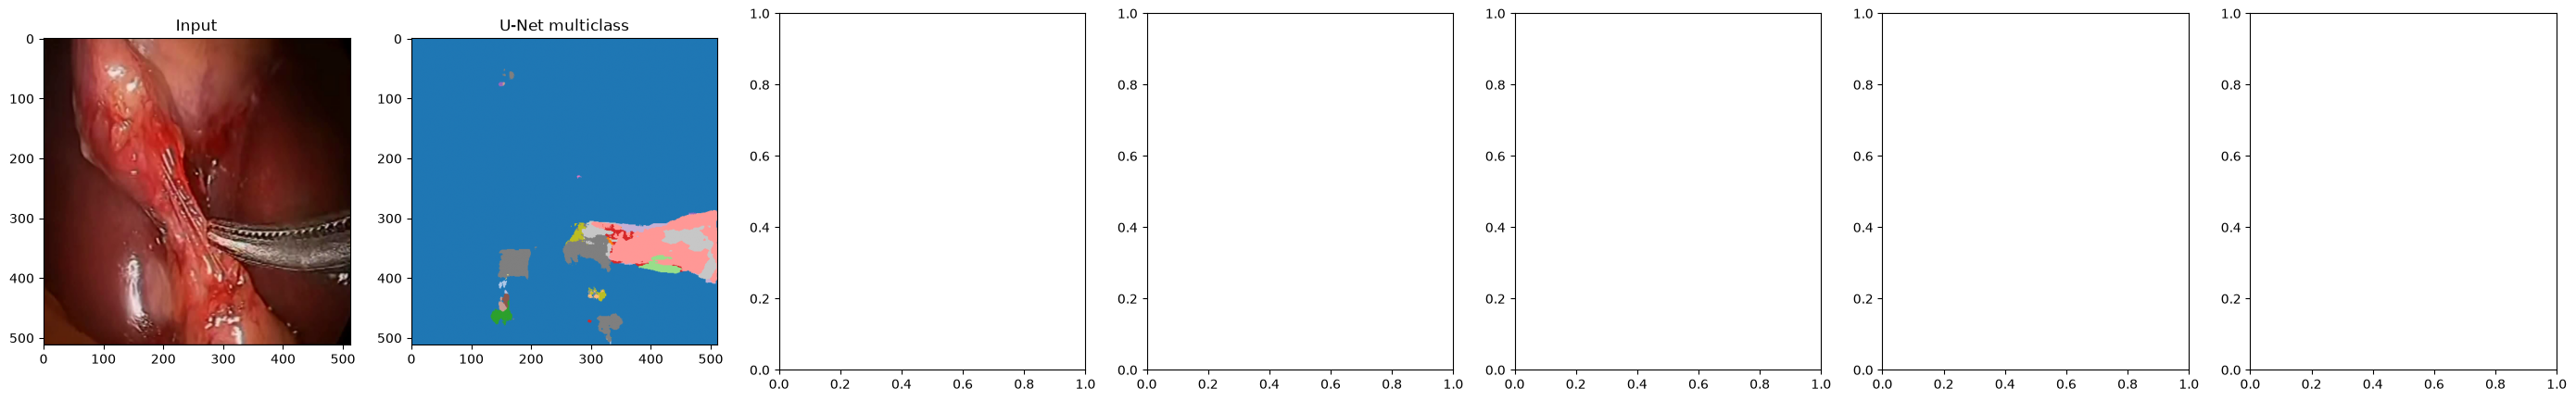

In [48]:
ffig, axes = plt.subplots(1, 7, figsize=(35, 5))

axes[0].imshow(result["image_rgb"])
axes[0].set_title("Input")

axes[1].imshow(result["predicted_mask"], cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
axes[1].set_title("U-Net multiclass")

axes[2].imshow(tool_mask, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Tool mask")

axes[3].imshow(result["tti_mask"], cmap="gray", vmin=0, vmax=255)
axes[3].set_title("TTI mask (U-Net)")

axes[4].imshow(result["depth_norm"], cmap="plasma", vmin=0, vmax=1)
axes[4].set_title("Depth Anything V2")

axes[5].imshow(result["contact_mask"], cmap="gray", vmin=0, vmax=255)
axes[5].set_title("Contact mask (depth fusion)")

axes[6].imshow(result["image_rgb"])
axes[6].imshow(result["tti_mask"], cmap="Reds", alpha=0.55, vmin=0, vmax=255)
axes[6].set_title("U-Net TTI overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(result["image_rgb"])
axes[0].set_title("Input")

for ax, selection in zip(axes[1:], ["low", "high"]):
    contact_mask = (
        fuse_tool_depth_quantile(
            tool_mask=result["tool_mask"],
            depth_map=result["depth_map"],
            quantile=DEPTH_QUANTILE,
            min_area=MIN_CONTACT_AREA,
            selection=selection
        )
    )

    ax.imshow(result["image_rgb"])

    ax.imshow(
        contact_mask,
        cmap="Reds",
        alpha=0.6,
        vmin=0,
        vmax=255
    )

    ax.set_title(f"Selection: {selection}")
    ax.axis("off")

axes[0].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
quantiles = [0.10, 0.20, 0.25, 0.30, 0.40]

fig, axes = plt.subplots(1, len(quantiles), figsize=(22, 4))

for ax, quantile in zip(axes, quantiles):
    contact_mask = (
        fuse_tool_depth_quantile(
            tool_mask=result["tool_mask"],
            depth_map=result["depth_map"],
            quantile=quantile,
            min_area=MIN_CONTACT_AREA,
            selection=DEPTH_SELECTION
        )
    )

    ax.imshow(result["image_rgb"])

    ax.imshow(
        contact_mask,
        cmap="Reds",
        alpha=0.6,
        vmin=0,
        vmax=255
    )

    ax.set_title(f"q={quantile}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sample_id = sample["id"]

cv2.imwrite(
    str(OUTPUT_DIR / f"{sample_id}_predicted_mask.png"),
    result["predicted_mask"].astype(np.uint8)
)

cv2.imwrite(
    str(OUTPUT_DIR / f"{sample_id}_tool_mask.png"),
    result["tool_mask"]
)

cv2.imwrite(
    str(OUTPUT_DIR / f"{sample_id}_contact_mask.png"),
    result["contact_mask"]
)

depth_uint8 = (result["depth_norm"] * 255.0).clip(0, 255).astype(np.uint8)

cv2.imwrite(
    str(OUTPUT_DIR / f"{sample_id}_depth.png"),
    depth_uint8
)

cv2.imwrite(
    str(OUTPUT_DIR / f"{sample_id}_tti_mask.png"),
    result["tti_mask"]
)

overlay = cv2.cvtColor(result["image_rgb"], cv2.COLOR_RGB2BGR)

contact_pixels = (result["contact_mask"] > 0)

overlay[contact_pixels] = (0.45 * overlay[contact_pixels].astype(np.float32) + 0.55 * np.array([0, 0, 255], dtype=np.float32)).clip(0, 255).astype(np.uint8)

cv2.imwrite(str(OUTPUT_DIR / f"{sample_id}_contact_overlay.png"), overlay)

print("Results saved to:", OUTPUT_DIR.resolve())

# Comparison
We compared two methods to detect tool-tissue contact in surgical videos. Both approaches use the same pipeline: first segment the surgical tool, then estimate depth with Depth Anything V2, and finally identify contact regions. The only difference is the segmentation model — one uses YOLO26-seg, the other uses U-Net. We evaluated which model gives better contact detection.

In [26]:
def create_contact_overlay(
    image_rgb,
    contact_mask,
    color=(255, 0, 0),
    alpha=0.55,
):
    image_rgb = image_rgb.copy()
    contact_mask = contact_mask > 127

    color_array = np.zeros_like(
        image_rgb,
        dtype=np.uint8
    )

    color_array[:, :] = color

    image_rgb[contact_mask] = (
        alpha * color_array[contact_mask]
        + (1.0 - alpha)
        * image_rgb[contact_mask]
    ).astype(np.uint8)

    return image_rgb


Descriptive statistics
                  pipeline  tool_area_percent  contact_area_percent  contact_over_tool_percent
YOLO26 + Depth Anything V2             7.2218                1.8681                    25.8674
 U-Net + Depth Anything V2             6.3748                4.8033                    75.3486

Descriptive ranking
                  pipeline  tool_area_percent  contact_area_percent  contact_over_tool_percent  tool_score  contact_score  contact_ratio_score  descriptive_score  rank
YOLO26 + Depth Anything V2             7.2218                1.8681                    25.8674      1.0000         0.6111               0.6567            81.6945     1
 U-Net + Depth Anything V2             6.3748                4.8033                    75.3486      0.8827         0.0000               0.0000            44.1357     2

Best according to this descriptive criterion: YOLO26 + Depth Anything V2


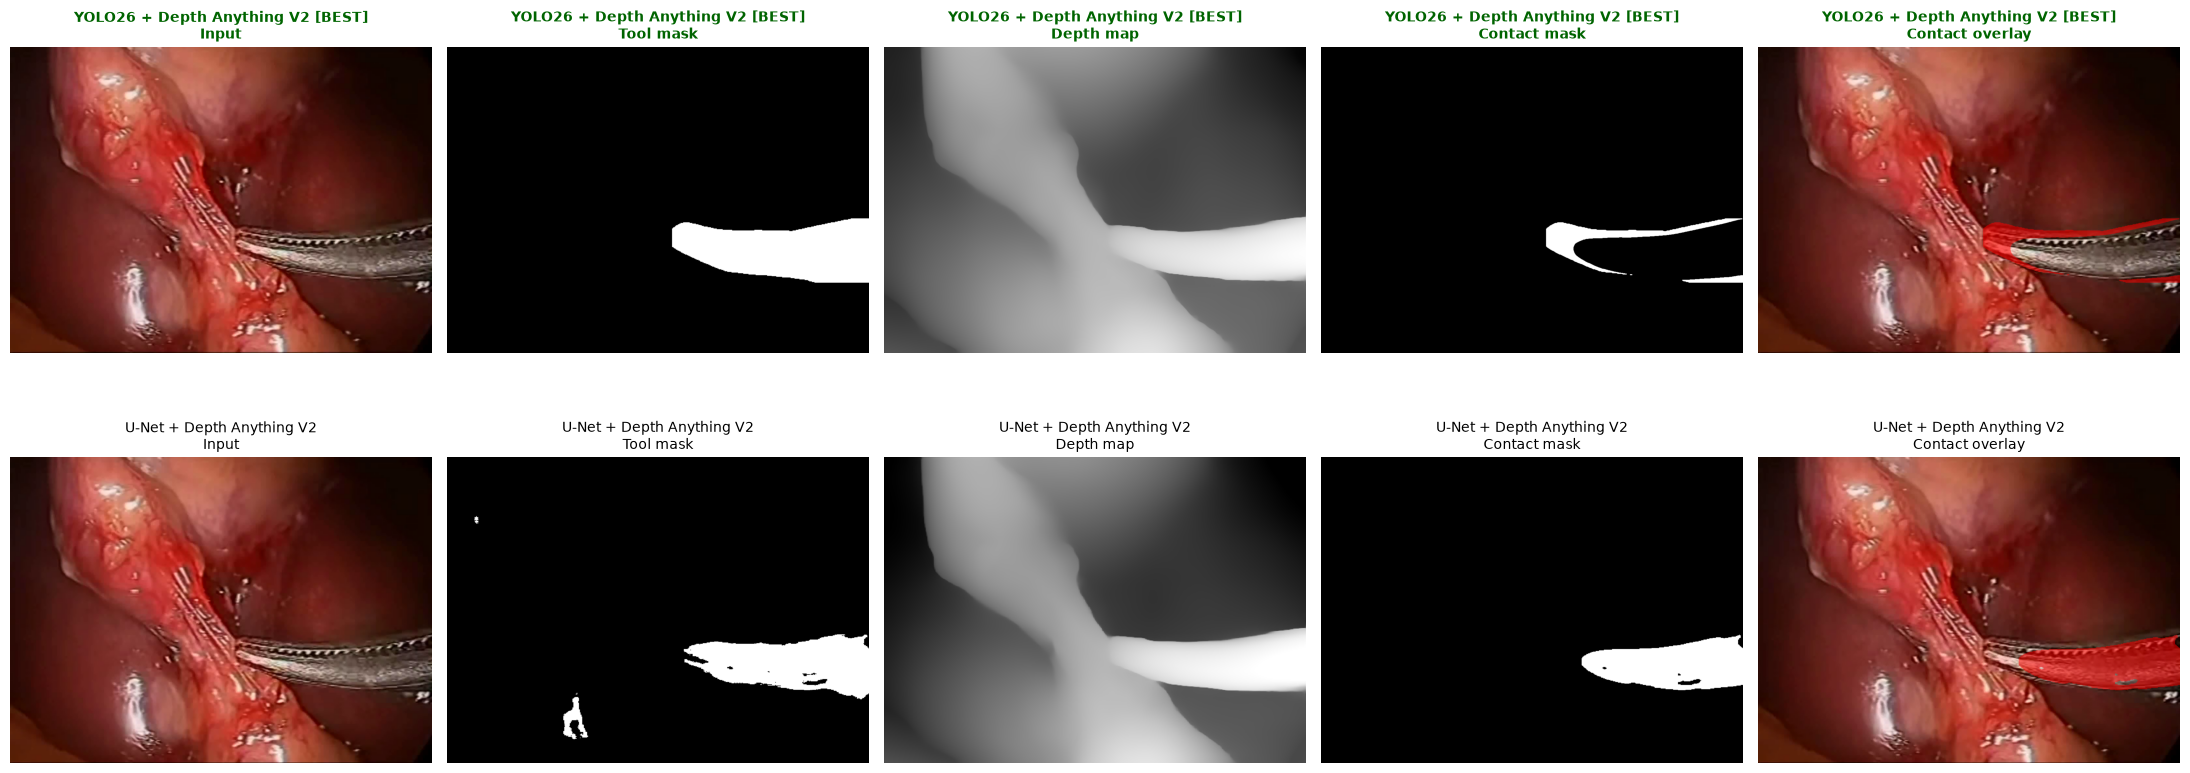


Comparison figure saved to:
/home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/comparison/adnansetlc100009_frame000000_yolo_unet_depth_comparison.png

Statistics saved to:
/home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/comparison/adnansetlc100009_frame000000_statistics.csv

Ranking saved to:
/home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/comparison/adnansetlc100009_frame000000_ranking.csv


In [27]:
# Execute this script from the project root.
PROJECT_ROOT = Path.cwd().resolve()

YOLO_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "yolo26"
    / "depth_yolo26"
)

UNET_DIR = PROJECT_ROOT / "outputs" / "unet"
COMPARISON_DIR = PROJECT_ROOT / "outputs" / "comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

FRAME_STEM = "adnansetlc100009_frame000000"


def load_color(path):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"Unable to read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def load_gray(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise RuntimeError(f"Unable to read mask: {path}")
    return image


def resize_image(image, shape):
    height, width = shape[:2]
    if image.shape[:2] == (height, width):
        return image
    return cv2.resize(
        image,
        (width, height),
        interpolation=cv2.INTER_NEAREST,
    )


def require_paths(paths):
    missing = [
        f"{name}: {path}"
        for name, path in paths.items()
        if not path.exists()
    ]
    if missing:
        raise FileNotFoundError(
            "Missing files:\n" + "\n".join(missing)
        )


def create_overlay(image_rgb, contact_mask):
    overlay = image_rgb.copy()
    contact = contact_mask > 127
    red = overlay.copy()
    red[:, :] = (255, 0, 0)
    overlay[contact] = (
        0.55 * red[contact]
        + 0.45 * overlay[contact]
    ).astype("uint8")
    return overlay


def mask_statistics(tool_mask, contact_mask):
    tool = tool_mask > 127
    contact = contact_mask > 127
    return {
        "tool_area_percent": 100.0 * float(tool.mean()),
        "contact_area_percent": 100.0 * float(contact.mean()),
        "contact_over_tool_percent": (
            100.0 * float(contact.sum()) / max(int(tool.sum()), 1)
        ),
    }


def create_comparison_score(statistics_df):
    """
    Descriptive score only.
    It rewards a larger detected tool region and penalizes excessive
    contact selection. It is not an accuracy score and does not use GT.
    """
    result = statistics_df.copy()
    result["tool_score"] = (
        result["tool_area_percent"]
        / result["tool_area_percent"].max()
    )
    result["contact_score"] = (
        1.0
        - result["contact_area_percent"]
        / result["contact_area_percent"].max()
    )
    result["contact_ratio_score"] = (
        1.0
        - result["contact_over_tool_percent"]
        / result["contact_over_tool_percent"].max()
    )
    result["descriptive_score"] = 100.0 * (
        0.50 * result["tool_score"]
        + 0.25 * result["contact_score"]
        + 0.25 * result["contact_ratio_score"]
    )
    result = result.sort_values(
        "descriptive_score",
        ascending=False,
    ).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    return result


# All files are PNG.
yolo_paths = {
    "input": YOLO_DIR / "input_yolo26.png",
    "tool": YOLO_DIR / "yolo26_tool_mask.png",
    "depth": YOLO_DIR / "depth_normalized_yolo26.png",
    "contact": YOLO_DIR / "contact_mask_yolo26.png",
}

unet_paths = {
    "input": (
        PROJECT_ROOT
        / "unet_dataset"
        / "images"
        / "test"
        / f"{FRAME_STEM}.png"
    ),
    "tool": UNET_DIR / f"{FRAME_STEM}_tool_mask.png",
    "depth": UNET_DIR / f"{FRAME_STEM}_depth.png",
    "contact": UNET_DIR / f"{FRAME_STEM}_contact_mask.png",
}

require_paths({
    **{f"YOLO {key}": value for key, value in yolo_paths.items()},
    **{f"U-Net {key}": value for key, value in unet_paths.items()},
})


# Load saved outputs.
yolo_input = load_color(yolo_paths["input"])
yolo_tool = load_gray(yolo_paths["tool"])
yolo_depth = load_color(yolo_paths["depth"])
yolo_contact = load_gray(yolo_paths["contact"])

unet_input = load_color(unet_paths["input"])
unet_tool = load_gray(unet_paths["tool"])
unet_depth = load_color(unet_paths["depth"])
unet_contact = load_gray(unet_paths["contact"])


# Use a common resolution.
target_shape = yolo_tool.shape

for name in [
    "yolo_input",
    "yolo_depth",
    "unet_input",
    "unet_tool",
    "unet_depth",
    "unet_contact",
]:
    globals()[name] = resize_image(
        globals()[name],
        target_shape,
    )


# Generate equivalent final overlays for both pipelines.
yolo_overlay = create_overlay(
    yolo_input,
    yolo_contact,
)
unet_overlay = create_overlay(
    unet_input,
    unet_contact,
)


# Descriptive statistics and ranking.
statistics_df = pd.DataFrame([
    {
        "pipeline": "YOLO26 + Depth Anything V2",
        **mask_statistics(yolo_tool, yolo_contact),
    },
    {
        "pipeline": "U-Net + Depth Anything V2",
        **mask_statistics(unet_tool, unet_contact),
    },
])

ranking_df = create_comparison_score(statistics_df)
best_pipeline = ranking_df.iloc[0]["pipeline"]

print("\nDescriptive statistics")
print(statistics_df.round(4).to_string(index=False))

print("\nDescriptive ranking")
print(ranking_df.round(4).to_string(index=False))

print(f"\nBest according to this descriptive criterion: {best_pipeline}")
print(
    "Warning: this ranking is not an accuracy evaluation because "
    "no contact ground-truth mask is available."
)


statistics_path = (
    COMPARISON_DIR
    / f"{FRAME_STEM}_statistics.csv"
)
ranking_path = (
    COMPARISON_DIR
    / f"{FRAME_STEM}_ranking.csv"
)

statistics_df.to_csv(statistics_path, index=False)
ranking_df.to_csv(ranking_path, index=False)


# Equivalent visual comparison.
fig, axes = plt.subplots(
    2,
    5,
    figsize=(22, 9),
)

rows = [
    (
        "YOLO26 + Depth Anything V2",
        [yolo_input, yolo_tool, yolo_depth, yolo_contact, yolo_overlay],
    ),
    (
        "U-Net + Depth Anything V2",
        [unet_input, unet_tool, unet_depth, unet_contact, unet_overlay],
    ),
]

column_titles = [
    "Input",
    "Tool mask",
    "Depth map",
    "Contact mask",
    "Contact overlay",
]

for row_index, (pipeline_name, images) in enumerate(rows):
    is_best = pipeline_name == best_pipeline

    for column_index, (title, image) in enumerate(
        zip(column_titles, images)
    ):
        axis = axes[row_index, column_index]
        axis.imshow(image, cmap="gray")
        axis.axis("off")
        axis.set_title(
            f"{pipeline_name}"
            f"{' [BEST]' if is_best else ''}\n{title}",
            fontsize=10,
            color="darkgreen" if is_best else "black",
            fontweight="bold" if is_best else "normal",
        )

        if is_best:
            for spine in axis.spines.values():
                spine.set_visible(True)
                spine.set_color("limegreen")
                spine.set_linewidth(3)

plt.tight_layout()

figure_path = (
    COMPARISON_DIR
    / f"{FRAME_STEM}_yolo_unet_depth_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("\nComparison figure saved to:")
print(figure_path.resolve())
print("\nStatistics saved to:")
print(statistics_path.resolve())
print("\nRanking saved to:")
print(ranking_path.resolve())

Both complete pipelines use the same Depth Anything V2 model and the same depth-based contact extraction procedure. The depth maps are therefore comparable and remain consistent across the two rows. The main difference is observed in the final contact masks: YOLO26 produces a more localized and conservative contact region, whereas U-Net generates a larger contact region covering most of the detected distal tool area. This difference is caused by the segmentation masks provided to the common depth-processing stage. Since no contact-region ground truth is available, the comparison is qualitative and descriptive rather than an accuracy ranking.